<a href="https://colab.research.google.com/github/eduloopezzz/TFG_IGENIERIADATO_EDUARDOLOPEZ/blob/main/TFGBAINGENIERIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import warnings
import os

warnings.filterwarnings('ignore')
RUTA_DATOS = './'

In [8]:
# ==============================================================================
# FASE 1: EXTRACCIÓN
# ==============================================================================

def extraer_delitos(ruta):
    """Extrae los delitos patrimoniales del Portal Estadístico de Criminalidad
    (Ministerio del Interior). Se extraen los 4 tipos por separado y se suman:
      - 5.1 Hurtos
      - 5.2 Robos con fuerza en las cosas
      - 5.3 Robos con violencia o intimidación
      - 5.4 Sustracción de vehículos"""
    df_raw = pd.read_excel(ruta + 'delitos economicos por provincia filtrado.xlsx', header=None)
    years = df_raw.iloc[6, 1:16].astype(int).tolist()

    registros = []
    provincia_actual = None
    for i in range(7, len(df_raw)):
        val = df_raw.iloc[i, 0]
        if pd.isna(val): continue
        val = str(val).strip()
        if val in ['Notas:', ''] or val.startswith('1)') or val.startswith('Fuente') \
                or val.startswith('Ministerio') or val.startswith('(*'): continue
        if val.startswith('5.'):
            datos = df_raw.iloc[i, 1:16].values
            for j, year in enumerate(years):
                registros.append({'Provincia_raw': provincia_actual, 'Tipo_Delito': val,
                                  'Año': year, 'Hechos': datos[j]})
        else:
            provincia_actual = val

    df = pd.DataFrame(registros)
    df['Hechos'] = pd.to_numeric(df['Hechos'], errors='coerce').fillna(0).astype(int)
    df = df[~df['Provincia_raw'].isin(['Total Nacional', 'En el extranjero', 'Desconocida'])]

    tipo_map = {
        '5.1.-Hurtos': 'Hurtos',
        '5.2.-Robos con fuerza en las cosas': 'Robos_Fuerza',
        '5.3.-Robos con violencia o intimidación': 'Robos_Violencia',
        '5.4.-Sustracción de vehículos': 'Sustraccion_Vehiculos'
    }
    df['Tipo_Clean'] = df['Tipo_Delito'].str.strip().map(tipo_map)

    df_pivot = df.pivot_table(index=['Provincia_raw', 'Año'], columns='Tipo_Clean',
                               values='Hechos', aggfunc='sum').reset_index()
    df_pivot.columns.name = None
    df_pivot['Delitos_Patrimoniales'] = df_pivot[
        ['Hurtos', 'Robos_Fuerza', 'Robos_Violencia', 'Sustraccion_Vehiculos']].sum(axis=1)

    print(f"[EXTRACCIÓN] Delitos: {df_pivot.shape[0]} registros, "
          f"{df_pivot['Provincia_raw'].nunique()} provincias")
    return df_pivot


def extraer_poblacion(ruta):
    """Combina Padrón Municipal (1996-2021) y Censo Anual (2021-2024).
    Se prioriza el Censo en caso de solapamiento."""
    registros = []
    df1 = pd.read_excel(ruta + 'poblacion por provincias 21-96.xlsx', header=None)
    for i in range(9, len(df1)):
        val = df1.iloc[i, 0]
        if pd.isna(val) or str(val).strip() in ['', 'Total', 'Notas:'] \
                or str(val).startswith('Fuente') or str(val).startswith('Instituto'): continue
        for j in range(1, 27):
            try:
                y = int(float(str(df1.iloc[7, j]).strip()))
                p = int(float(str(df1.iloc[i, j]).strip()))
                registros.append({'Provincia_raw': str(val).strip(), 'Año': y, 'Poblacion': p})
            except: pass

    df2 = pd.read_excel(ruta + 'poblacion provincias 21-24.xlsx', header=None)
    for i in range(8, len(df2)):
        val = df2.iloc[i, 0]
        if pd.isna(val) or str(val).strip() in ['', 'Notas:'] \
                or str(val).startswith('Fuente') or str(val).startswith('Instituto'): continue
        for j in range(1, 5):
            try:
                y = int(float(str(df2.iloc[7, j]).strip()))
                p = int(float(str(df2.iloc[i, j]).strip()))
                registros.append({'Provincia_raw': str(val).strip(), 'Año': y, 'Poblacion': p})
            except: pass

    df = pd.DataFrame(registros).drop_duplicates(subset=['Provincia_raw', 'Año'], keep='last')
    print(f"[EXTRACCIÓN] Población: {df.shape[0]} registros, {df['Provincia_raw'].nunique()} provincias")
    return df


def extraer_paro(ruta):
    """Extrae la tasa de paro trimestral de la EPA (INE), sección 'Ambos sexos',
    y la promedia a nivel anual."""
    df_raw = pd.read_excel(ruta + 'tasa paro provincias (cuatrimestres) 02-24.xlsx', header=None)

    paro_col = empleo_col = None
    for c in range(df_raw.shape[1]):
        h = df_raw.iloc[6, c]
        if isinstance(h, str):
            if 'paro' in h.lower() and paro_col is None: paro_col = c
            elif 'empleo' in h.lower() and empleo_col is None: empleo_col = c

    trimestres = []
    for c in range(paro_col, empleo_col):
        q = df_raw.iloc[7, c]
        if pd.isna(q): continue
        trimestres.append((c, str(q)))

    registros = []
    for i in range(9, 63):
        val = df_raw.iloc[i, 0]
        if pd.isna(val): continue
        val = str(val).strip()
        if val in ['Ambos sexos', 'Hombres', 'Mujeres', '', 'Total Nacional']: continue
        for col_idx, q in trimestres:
            dv = df_raw.iloc[i, col_idx]
            if not pd.isna(dv):
                try: registros.append({'Provincia_raw': val, 'Año': int(q[:4]), 'Tasa_Paro': float(dv)})
                except: pass

    df = pd.DataFrame(registros)
    df_anual = df.groupby(['Provincia_raw', 'Año'])['Tasa_Paro'].mean().reset_index()
    df_anual['Tasa_Paro'] = df_anual['Tasa_Paro'].round(2)
    print(f"[EXTRACCIÓN] Paro: {df_anual.shape[0]} registros, {df_anual['Provincia_raw'].nunique()} provincias")
    return df_anual


def extraer_renta(ruta):
    """Extrae renta neta media por persona (INE). Periodo: 2015-2023."""
    df_raw = pd.read_excel(ruta + 'renta neta media por persona 15-23.xlsx', header=None)
    registros = []
    for i in range(9, len(df_raw)):
        val = df_raw.iloc[i, 0]
        if pd.isna(val): continue
        val = str(val).strip()
        if val in ['', 'Total Nacional', 'Notas:'] or val.startswith('El concepto') \
                or val.startswith('Fuente') or val.startswith('Instituto'): continue
        for j in range(1, 10):
            yv = df_raw.iloc[7, j]; dv = df_raw.iloc[i, j]
            if pd.isna(yv) or pd.isna(dv) or str(dv).strip() in ['', '..']: continue
            try: registros.append({'Provincia_raw': val, 'Año': int(float(str(yv).strip())),
                                   'Renta_Neta_Media': float(dv)})
            except: pass
    df = pd.DataFrame(registros)
    print(f"[EXTRACCIÓN] Renta: {df.shape[0]} registros, {df['Provincia_raw'].nunique()} provincias")
    return df

In [9]:
# ==============================================================================
# FASE 2: TRANSFORMACIÓN
# ==============================================================================

NOMBRE_ESTANDAR = {
    'Balears (Illes)': 'Balears, Illes', 'Coruña (A)': 'Coruña, A',
    'Palmas (Las)': 'Palmas, Las', 'Rioja (La)': 'Rioja, La',
    '01 Araba/Álava': 'Araba/Álava', '02 Albacete': 'Albacete',
    '03 Alicante/Alacant': 'Alicante/Alacant', '04 Almería': 'Almería',
    '05 Ávila': 'Ávila', '06 Badajoz': 'Badajoz',
    '07 Balears, Illes': 'Balears, Illes', '08 Barcelona': 'Barcelona',
    '09 Burgos': 'Burgos', '10 Cáceres': 'Cáceres',
    '11 Cádiz': 'Cádiz', '12 Castellón/Castelló': 'Castellón/Castelló',
    '13 Ciudad Real': 'Ciudad Real', '14 Córdoba': 'Córdoba',
    '15 Coruña, A': 'Coruña, A', '16 Cuenca': 'Cuenca',
    '17 Girona': 'Girona', '18 Granada': 'Granada',
    '19 Guadalajara': 'Guadalajara', '20 Gipuzkoa': 'Gipuzkoa',
    '21 Huelva': 'Huelva', '22 Huesca': 'Huesca',
    '23 Jaén': 'Jaén', '24 León': 'León',
    '25 Lleida': 'Lleida', '26 Rioja, La': 'Rioja, La',
    '27 Lugo': 'Lugo', '28 Madrid': 'Madrid',
    '29 Málaga': 'Málaga', '30 Murcia': 'Murcia',
    '31 Navarra': 'Navarra', '32 Ourense': 'Ourense',
    '33 Asturias': 'Asturias', '34 Palencia': 'Palencia',
    '35 Palmas, Las': 'Palmas, Las', '36 Pontevedra': 'Pontevedra',
    '37 Salamanca': 'Salamanca', '38 Santa Cruz de Tenerife': 'Santa Cruz de Tenerife',
    '39 Cantabria': 'Cantabria', '40 Segovia': 'Segovia',
    '41 Sevilla': 'Sevilla', '42 Soria': 'Soria',
    '43 Tarragona': 'Tarragona', '44 Teruel': 'Teruel',
    '45 Toledo': 'Toledo', '46 Valencia/València': 'Valencia/València',
    '47 Valladolid': 'Valladolid', '48 Bizkaia': 'Bizkaia',
    '49 Zamora': 'Zamora', '50 Zaragoza': 'Zaragoza',
    '51 Ceuta': 'Ceuta', '52 Melilla': 'Melilla',
}

SUPERFICIE_KM2 = {
    'Araba/Álava': 3037, 'Albacete': 14926, 'Alicante/Alacant': 5817,
    'Almería': 8775, 'Ávila': 8050, 'Badajoz': 21766,
    'Balears, Illes': 4992, 'Barcelona': 7728, 'Bizkaia': 2217,
    'Burgos': 14291, 'Cáceres': 19868, 'Cádiz': 7436,
    'Cantabria': 5321, 'Castellón/Castelló': 6632, 'Ciudad Real': 19813,
    'Córdoba': 13771, 'Coruña, A': 7950, 'Cuenca': 17141,
    'Gipuzkoa': 1980, 'Girona': 5910, 'Granada': 12647,
    'Guadalajara': 12214, 'Huelva': 10128, 'Huesca': 15636,
    'Jaén': 13496, 'León': 15581, 'Lleida': 12150,
    'Lugo': 9857, 'Madrid': 8028, 'Málaga': 7308,
    'Murcia': 11313, 'Navarra': 10391, 'Ourense': 7273,
    'Asturias': 10604, 'Palencia': 8053, 'Palmas, Las': 4066,
    'Pontevedra': 4495, 'Rioja, La': 5045, 'Salamanca': 12350,
    'Santa Cruz de Tenerife': 3381, 'Segovia': 6923, 'Sevilla': 14036,
    'Soria': 10307, 'Tarragona': 6303, 'Teruel': 14810,
    'Toledo': 15370, 'Valencia/València': 10806, 'Valladolid': 8110,
    'Zamora': 10561, 'Zaragoza': 17274, 'Ceuta': 19, 'Melilla': 13,
}


def estandarizar_provincia(nombre):
    if pd.isna(nombre): return None
    nombre = str(nombre).strip()
    return NOMBRE_ESTANDAR.get(nombre, nombre)


def transformar(df_delitos, df_pob, df_paro, df_renta, year_min=2010, year_max=2024):
    for df in [df_delitos, df_pob, df_paro, df_renta]:
        df['Provincia'] = df['Provincia_raw'].apply(estandarizar_provincia)
        df.drop(df[df['Provincia'] == 'Total Nacional'].index, inplace=True, errors='ignore')

    provs_comunes = (set(df_delitos['Provincia']) & set(df_pob['Provincia'])
                     & set(df_paro['Provincia']) & set(df_renta['Provincia']))
    print(f"[TRANSFORMACIÓN] Provincias alineadas: {len(provs_comunes)}")

    for df in [df_delitos, df_pob, df_paro, df_renta]:
        df.drop(df[(df['Año'] < year_min) | (df['Año'] > year_max)].index, inplace=True)

    cols_del = ['Provincia', 'Año', 'Hurtos', 'Robos_Fuerza',
                'Robos_Violencia', 'Sustraccion_Vehiculos', 'Delitos_Patrimoniales']
    master = df_delitos[cols_del].merge(
        df_pob[['Provincia', 'Año', 'Poblacion']], on=['Provincia', 'Año'], how='left'
    ).merge(
        df_paro[['Provincia', 'Año', 'Tasa_Paro']], on=['Provincia', 'Año'], how='left'
    ).merge(
        df_renta[['Provincia', 'Año', 'Renta_Neta_Media']], on=['Provincia', 'Año'], how='left'
    )

    master['Tasa_Delitos_100k'] = (master['Delitos_Patrimoniales'] / master['Poblacion'] * 100000).round(2)
    master['Hurtos_100k'] = (master['Hurtos'] / master['Poblacion'] * 100000).round(2)
    master['Robos_Fuerza_100k'] = (master['Robos_Fuerza'] / master['Poblacion'] * 100000).round(2)
    master['Robos_Violencia_100k'] = (master['Robos_Violencia'] / master['Poblacion'] * 100000).round(2)
    master['Sustraccion_Vehiculos_100k'] = (master['Sustraccion_Vehiculos'] / master['Poblacion'] * 100000).round(2)
    master['Densidad_Poblacion'] = (master['Poblacion'] / master['Provincia'].map(SUPERFICIE_KM2)).round(2)
    master['Dummy_COVID'] = master['Año'].apply(lambda x: 1 if x in [2020, 2021] else 0)

    # Interpolación lineal de Renta para años sin datos
    nulos_antes = master['Renta_Neta_Media'].isna().sum()
    for prov in master['Provincia'].unique():
        mask = master['Provincia'] == prov
        sub = master.loc[mask].sort_values('Año')
        if sub['Renta_Neta_Media'].isna().any():
            known = sub.dropna(subset=['Renta_Neta_Media'])
            if len(known) >= 2:
                coeffs = np.polyfit(known['Año'].values, known['Renta_Neta_Media'].values, 1)
                for idx in sub[sub['Renta_Neta_Media'].isna()].index:
                    val_interp = round(np.polyval(coeffs, master.loc[idx, 'Año']), 0)
                    if val_interp < 0: val_interp = known['Renta_Neta_Media'].min() * 0.8
                    master.loc[idx, 'Renta_Neta_Media'] = val_interp
    print(f"[TRANSFORMACIÓN] Renta interpolada: {nulos_antes} nulos → {master['Renta_Neta_Media'].isna().sum()}")

    master = master[['Provincia', 'Año',
                      'Hurtos', 'Robos_Fuerza', 'Robos_Violencia',
                      'Sustraccion_Vehiculos', 'Delitos_Patrimoniales', 'Poblacion',
                      'Tasa_Delitos_100k', 'Hurtos_100k', 'Robos_Fuerza_100k',
                      'Robos_Violencia_100k', 'Sustraccion_Vehiculos_100k',
                      'Tasa_Paro', 'Renta_Neta_Media', 'Densidad_Poblacion', 'Dummy_COVID']]
    return master.sort_values(['Provincia', 'Año']).reset_index(drop=True)

In [10]:
# ==============================================================================
# FASE 3: CARGA (Load) y VALIDACIÓN
# ==============================================================================

def validar_y_guardar(master, ruta_salida='base_datos_maestra.csv'):
    print(f"\n{'='*60}")
    print("BASE DE DATOS MAESTRA - VALIDACIÓN FINAL")
    print('='*60)
    print(f"Dimensiones: {master.shape[0]} filas × {master.shape[1]} columnas")
    print(f"Provincias: {master['Provincia'].nunique()}")
    print(f"Años: {sorted(master['Año'].unique())}")
    print(f"\nValores nulos: {master.isnull().sum().sum()}")
    print(f"\nEstadísticas descriptivas:")
    print(master[['Tasa_Delitos_100k', 'Tasa_Paro', 'Renta_Neta_Media',
                   'Densidad_Poblacion']].describe().round(2).to_string())
    master.to_csv(ruta_salida, index=False, encoding='utf-8-sig')
    print(f"\n[CARGA] Exportado: {ruta_salida}")
    return master


if __name__ == '__main__':
    df_delitos = extraer_delitos(RUTA_DATOS)
    df_poblacion = extraer_poblacion(RUTA_DATOS)
    df_paro = extraer_paro(RUTA_DATOS)
    df_renta = extraer_renta(RUTA_DATOS)
    master = transformar(df_delitos, df_poblacion, df_paro, df_renta, 2010, 2024)
    master = validar_y_guardar(master, 'base_datos_maestra.csv')

[EXTRACCIÓN] Delitos: 780 registros, 52 provincias
[EXTRACCIÓN] Población: 1456 registros, 52 provincias
[EXTRACCIÓN] Paro: 1248 registros, 52 provincias
[EXTRACCIÓN] Renta: 456 registros, 52 provincias
[TRANSFORMACIÓN] Provincias alineadas: 52
[TRANSFORMACIÓN] Renta interpolada: 324 nulos → 0

BASE DE DATOS MAESTRA - VALIDACIÓN FINAL
Dimensiones: 780 filas × 17 columnas
Provincias: 52
Años: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Valores nulos: 0

Estadísticas descriptivas:
       Tasa_Delitos_100k  Tasa_Paro  Renta_Neta_Media  Densidad_Poblacion
count             780.00     780.00            780.00              780.00
mean             1751.06      18.25          11084.17              335.31
std               795.29       7.36           2613.91             1056.80
min               356.

In [12]:
# ─── Configuración global de estilo ──────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150,
    'savefig.dpi': 200,
    'savefig.bbox': 'tight',
    'savefig.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
})

# Paleta de colores
C_AZUL      = '#2E75B6'
C_AZUL_OSC  = '#1F497D'
C_GRIS      = '#595959'
C_NARANJA   = '#E36C09'
C_VERDE     = '#375623'
C_ROJO      = '#C0392B'
C_AMARILLO  = '#F1C40F'
C_CLARO     = '#BDD7EE'

COLORES_TIPO = {
    'Hurtos':                '#2E75B6',
    'Robos_Fuerza':          '#E36C09',
    'Robos_Violencia':       '#C0392B',
    'Sustraccion_Vehiculos': '#375623',
}

os.makedirs('./figuras', exist_ok=True)

Fig 1 — Tabla de integridad post-ETL


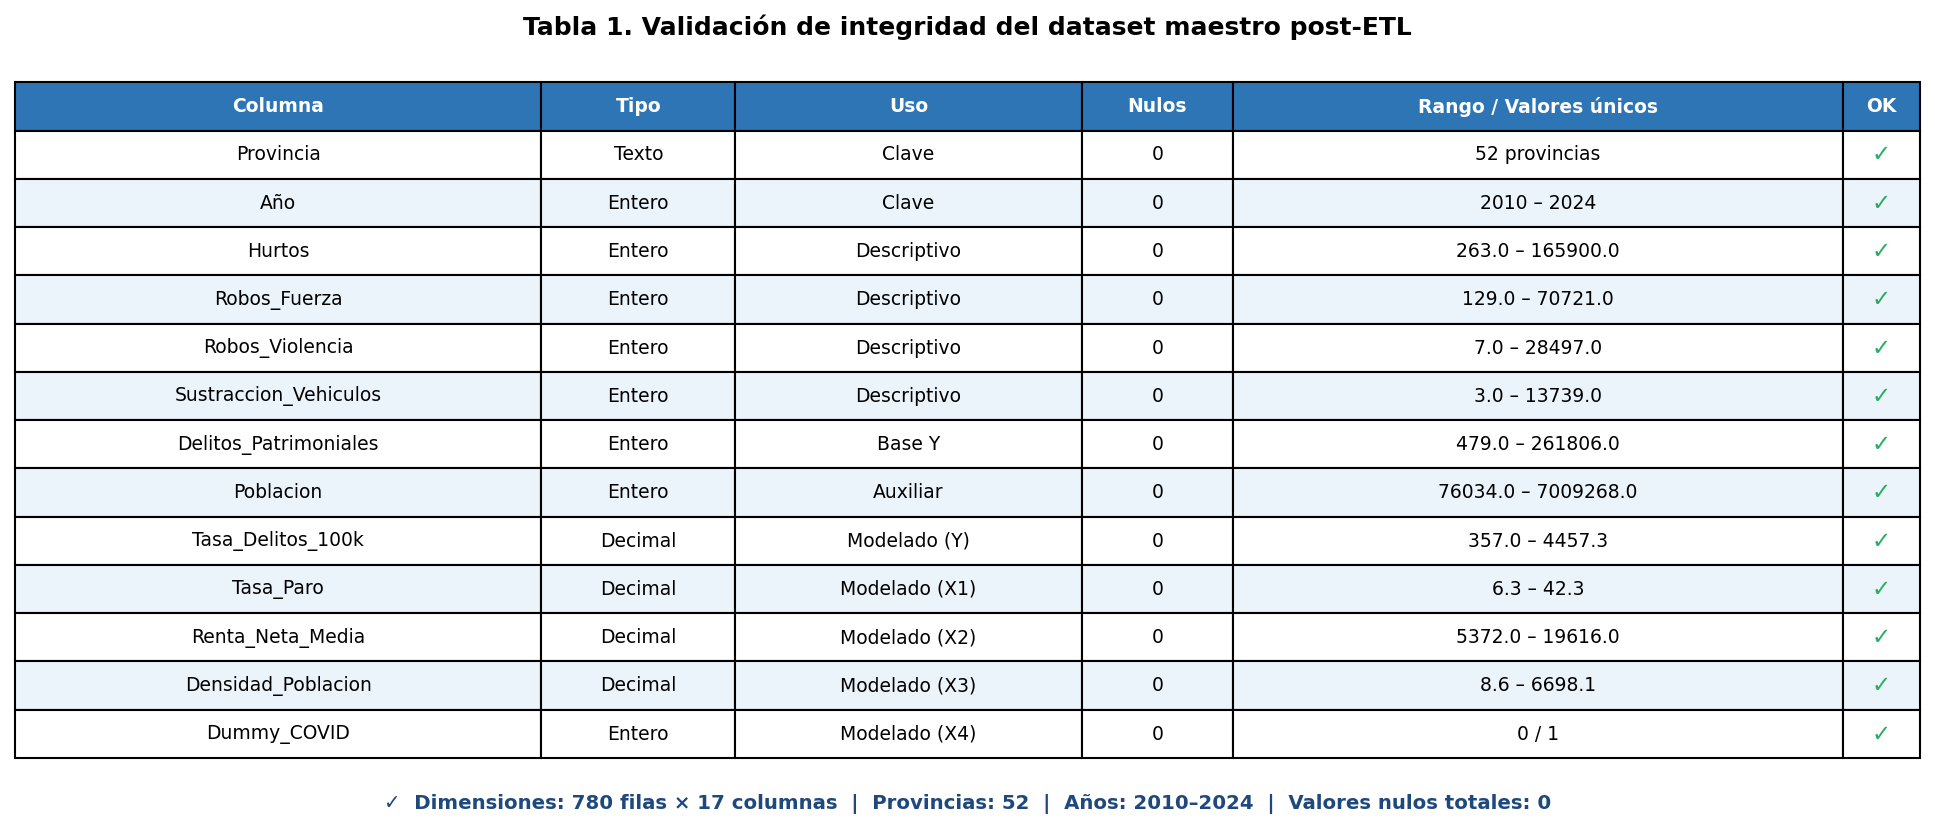

In [13]:
# ==============================================================================
# FIG 1 — TABLA DE INTEGRIDAD POST-ETL
# ==============================================================================
print("Fig 1 — Tabla de integridad post-ETL")

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.axis('off')

# Construir datos de la tabla
cols_check = {
    'Provincia':                 ('Texto', 'Clave'),
    'Año':                       ('Entero', 'Clave'),
    'Hurtos':                    ('Entero', 'Descriptivo'),
    'Robos_Fuerza':              ('Entero', 'Descriptivo'),
    'Robos_Violencia':           ('Entero', 'Descriptivo'),
    'Sustraccion_Vehiculos':     ('Entero', 'Descriptivo'),
    'Delitos_Patrimoniales':     ('Entero', 'Base Y'),
    'Poblacion':                 ('Entero', 'Auxiliar'),
    'Tasa_Delitos_100k':         ('Decimal', 'Modelado (Y)'),
    'Tasa_Paro':                 ('Decimal', 'Modelado (X1)'),
    'Renta_Neta_Media':          ('Decimal', 'Modelado (X2)'),
    'Densidad_Poblacion':        ('Decimal', 'Modelado (X3)'),
    'Dummy_COVID':               ('Entero', 'Modelado (X4)'),
}

table_data = [['Columna', 'Tipo', 'Uso', 'Nulos', 'Rango / Valores únicos', 'OK']]
for col, (tipo, uso) in cols_check.items():
    if col in master.columns:
        nulos = master[col].isna().sum()
        if master[col].dtype == object:
            rango = f"{master[col].nunique()} provincias"
        elif col == 'Año':
            rango = f"{int(master[col].min())} – {int(master[col].max())}"
        elif col == 'Dummy_COVID':
            rango = "0 / 1"
        elif pd.api.types.is_numeric_dtype(master[col]):
            rango = f"{master[col].min():.1f} – {master[col].max():.1f}"
        else:
            rango = f"{master[col].nunique()} valores únicos"
        ok = '✓' if nulos == 0 else f'✗ ({nulos})'
        table_data.append([col, tipo, uso, str(nulos), rango, ok])

n_rows = len(table_data)
n_cols = len(table_data[0])

table = ax.table(
    cellText=table_data[1:],
    colLabels=table_data[0],
    cellLoc='center',
    loc='center',
    bbox=[0, 0.05, 1, 0.92]
)
table.auto_set_font_size(False)
table.set_fontsize(9)

for j in range(n_cols):
    cell = table[0, j]
    cell.set_facecolor(C_AZUL)
    cell.set_text_props(color='white', fontweight='bold')

for i in range(1, n_rows):
    for j in range(n_cols):
        cell = table[i, j]
        cell.set_facecolor('#EBF3FB' if i % 2 == 0 else 'white')
        if j == n_cols - 1:
            txt = table_data[i][j]
            cell.set_text_props(color='#27AE60' if '✓' in txt else C_ROJO,
                                fontweight='bold', fontsize=11)

table.auto_set_column_width(list(range(n_cols)))

# Resumen inferior
total_nulos = master[list(cols_check.keys())].isna().sum().sum()
fig.text(0.5, 0.01,
         f"✓  Dimensiones: {master.shape[0]} filas × {master.shape[1]} columnas  |  "
         f"Provincias: {master['Provincia'].nunique()}  |  "
         f"Años: {int(master['Año'].min())}–{int(master['Año'].max())}  |  "
         f"Valores nulos totales: {total_nulos}",
         ha='center', fontsize=9.5, color=C_AZUL_OSC, fontweight='bold')

ax.set_title('Tabla 1. Validación de integridad del dataset maestro post-ETL',
             pad=12, fontsize=12)
plt.tight_layout()
plt.savefig('./figuras/fig1_tabla_integridad.png')

Fig 2 — Estadísticas descriptivas


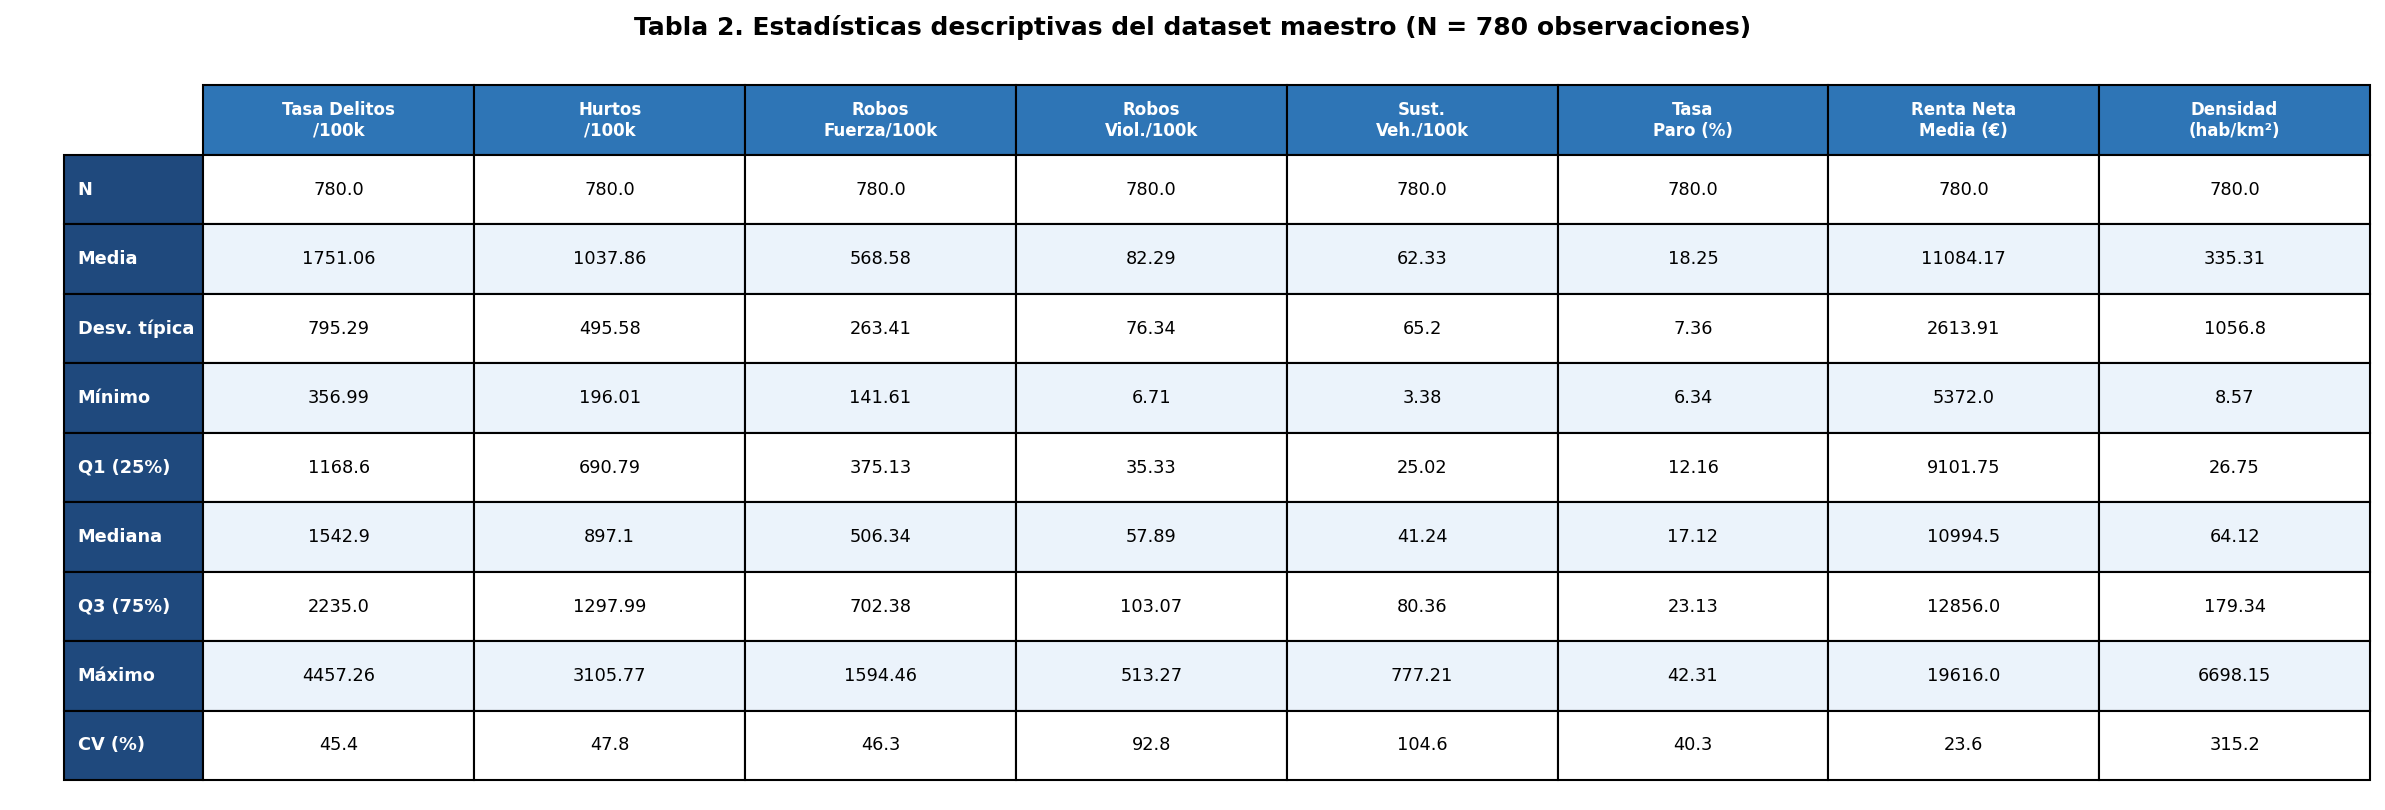

In [14]:
# ==============================================================================
# FIG 2 — ESTADÍSTICAS DESCRIPTIVAS COMPLETAS
# ==============================================================================
print("Fig 2 — Estadísticas descriptivas")

vars_desc = ['Tasa_Delitos_100k', 'Hurtos_100k', 'Robos_Fuerza_100k',
             'Robos_Violencia_100k', 'Sustraccion_Vehiculos_100k',
             'Tasa_Paro', 'Renta_Neta_Media', 'Densidad_Poblacion']

desc = master[vars_desc].describe().round(2)
desc.loc['cv (%)'] = (desc.loc['std'] / desc.loc['mean'] * 100).round(1)

etiquetas_filas = {
    'count': 'N',
    'mean': 'Media',
    'std': 'Desv. típica',
    'min': 'Mínimo',
    '25%': 'Q1 (25%)',
    '50%': 'Mediana',
    '75%': 'Q3 (75%)',
    'max': 'Máximo',
    'cv (%)': 'CV (%)',
}
desc.index = [etiquetas_filas.get(i, i) for i in desc.index]

col_labels_short = [
    'Tasa Delitos\n/100k', 'Hurtos\n/100k', 'Robos\nFuerza/100k',
    'Robos\nViol./100k', 'Sust.\nVeh./100k',
    'Tasa\nParo (%)', 'Renta Neta\nMedia (€)', 'Densidad\n(hab/km²)',
]

fig, ax = plt.subplots(figsize=(16, 5.5))
ax.axis('off')

table = ax.table(
    cellText=desc.values,
    rowLabels=desc.index,
    colLabels=col_labels_short,
    cellLoc='center',
    loc='center',
    bbox=[0.08, 0.02, 0.92, 0.94]
)
table.auto_set_font_size(False)
table.set_fontsize(8.5)

n_r, n_c = desc.shape
for j in range(n_c):
    table[0, j].set_facecolor(C_AZUL)
    table[0, j].set_text_props(color='white', fontweight='bold', fontsize=8)

for i in range(1, n_r + 1):
    table[i, -1].set_facecolor('#EBF3FB' if i % 2 == 0 else 'white')
    for j in range(-1, n_c):
        cell = table[i, j]
        if j == -1:
            cell.set_facecolor(C_AZUL_OSC)
            cell.set_text_props(color='white', fontweight='bold', fontsize=8.5)
        else:
            cell.set_facecolor('#EBF3FB' if i % 2 == 0 else 'white')

ax.set_title('Tabla 2. Estadísticas descriptivas del dataset maestro (N = 780 observaciones)',
             pad=10, fontsize=12)
plt.tight_layout()
plt.savefig('./figuras/fig2_estadisticas_descriptivas.png')
plt.show()


Fig 3 — Evolución temporal tasa de delitos


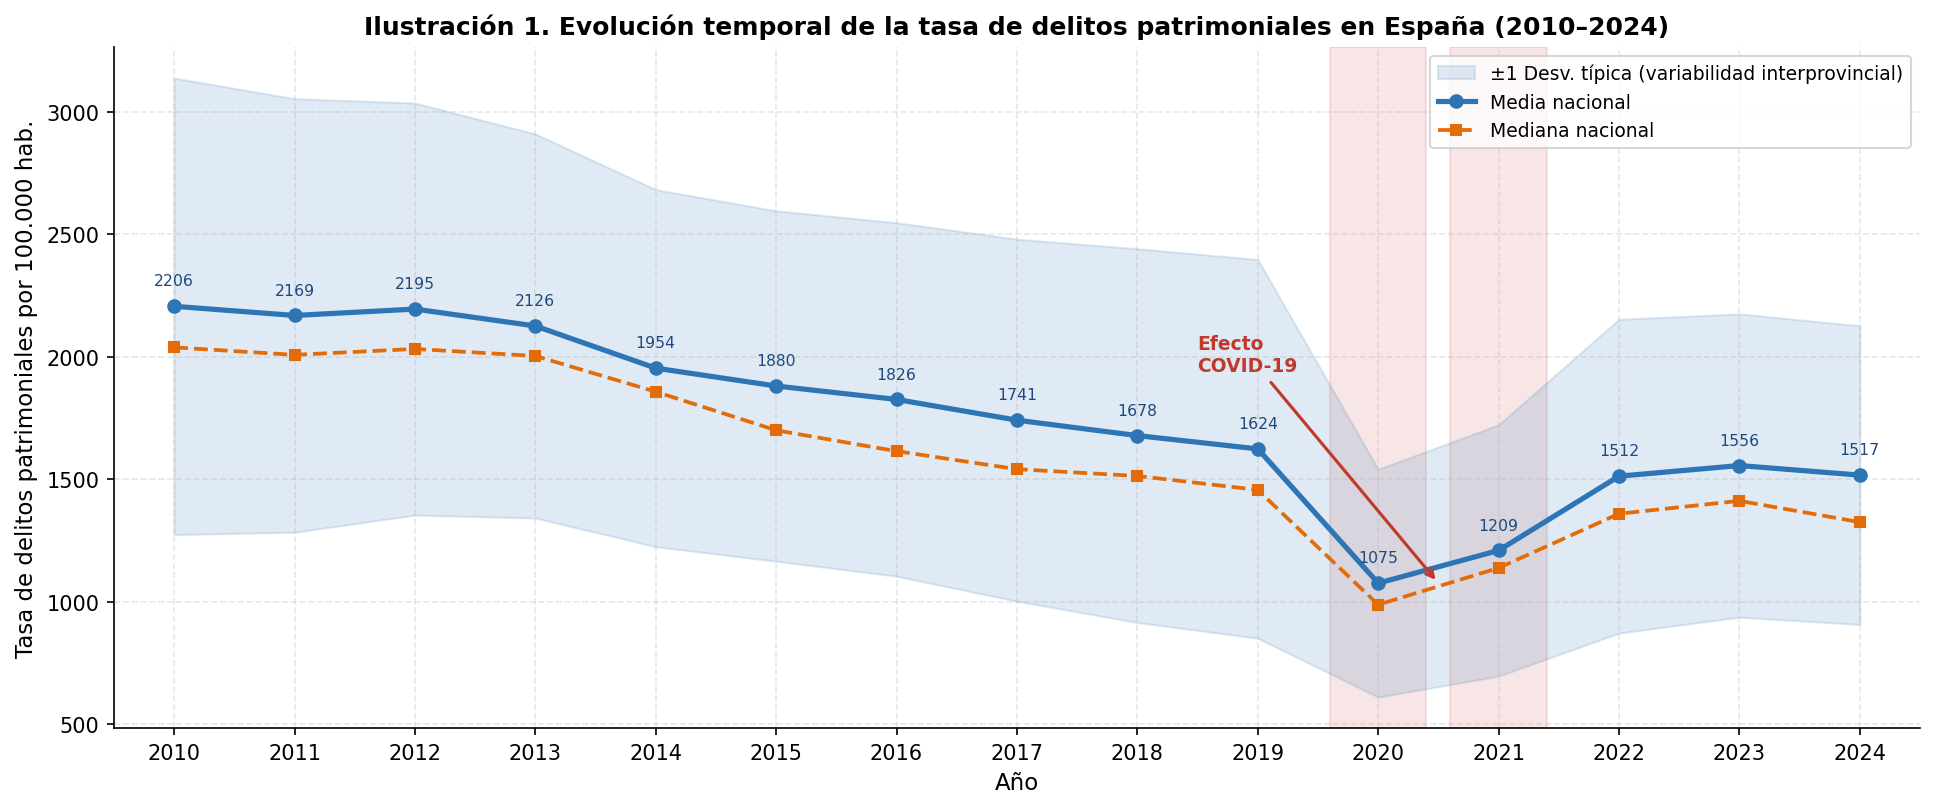

In [15]:
# ==============================================================================
# FIG 3 — EVOLUCIÓN TEMPORAL DE LA TASA DE DELITOS (media nacional)
# ==============================================================================
print("Fig 3 — Evolución temporal tasa de delitos")

evol = master.groupby('Año')['Tasa_Delitos_100k'].agg(['mean', 'median', 'std']).reset_index()

fig, ax = plt.subplots(figsize=(13, 5.5))

ax.fill_between(evol['Año'],
                evol['mean'] - evol['std'],
                evol['mean'] + evol['std'],
                alpha=0.15, color=C_AZUL, label='±1 Desv. típica (variabilidad interprovincial)')

ax.plot(evol['Año'], evol['mean'], color=C_AZUL, linewidth=2.5,
        marker='o', markersize=6, label='Media nacional')
ax.plot(evol['Año'], evol['median'], color=C_NARANJA, linewidth=1.8,
        linestyle='--', marker='s', markersize=5, label='Mediana nacional')

# Anotación COVID
for yr in [2020, 2021]:
    ax.axvspan(yr - 0.4, yr + 0.4, alpha=0.12, color=C_ROJO, zorder=0)
ax.annotate('Efecto\nCOVID-19', xy=(2020.5, evol.loc[evol['Año'] == 2020, 'mean'].values[0]),
            xytext=(2018.5, evol['mean'].max() * 0.88),
            arrowprops=dict(arrowstyle='->', color=C_ROJO, lw=1.5),
            fontsize=9, color=C_ROJO, fontweight='bold')

# Anotaciones de valor
for _, row in evol.iterrows():
    ax.annotate(f"{row['mean']:.0f}",
                xy=(row['Año'], row['mean']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=7.5, color=C_AZUL_OSC)

ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('Tasa de delitos patrimoniales por 100.000 hab.', fontsize=11)
ax.set_title('Ilustración 1. Evolución temporal de la tasa de delitos patrimoniales en España (2010–2024)',
             fontsize=12)
ax.set_xticks(evol['Año'])
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(2009.5, 2024.5)

plt.tight_layout()
plt.savefig('./figuras/fig3_evolucion_temporal_delitos.png')
plt.show()


Fig 4 — Distribución de la tasa de delitos


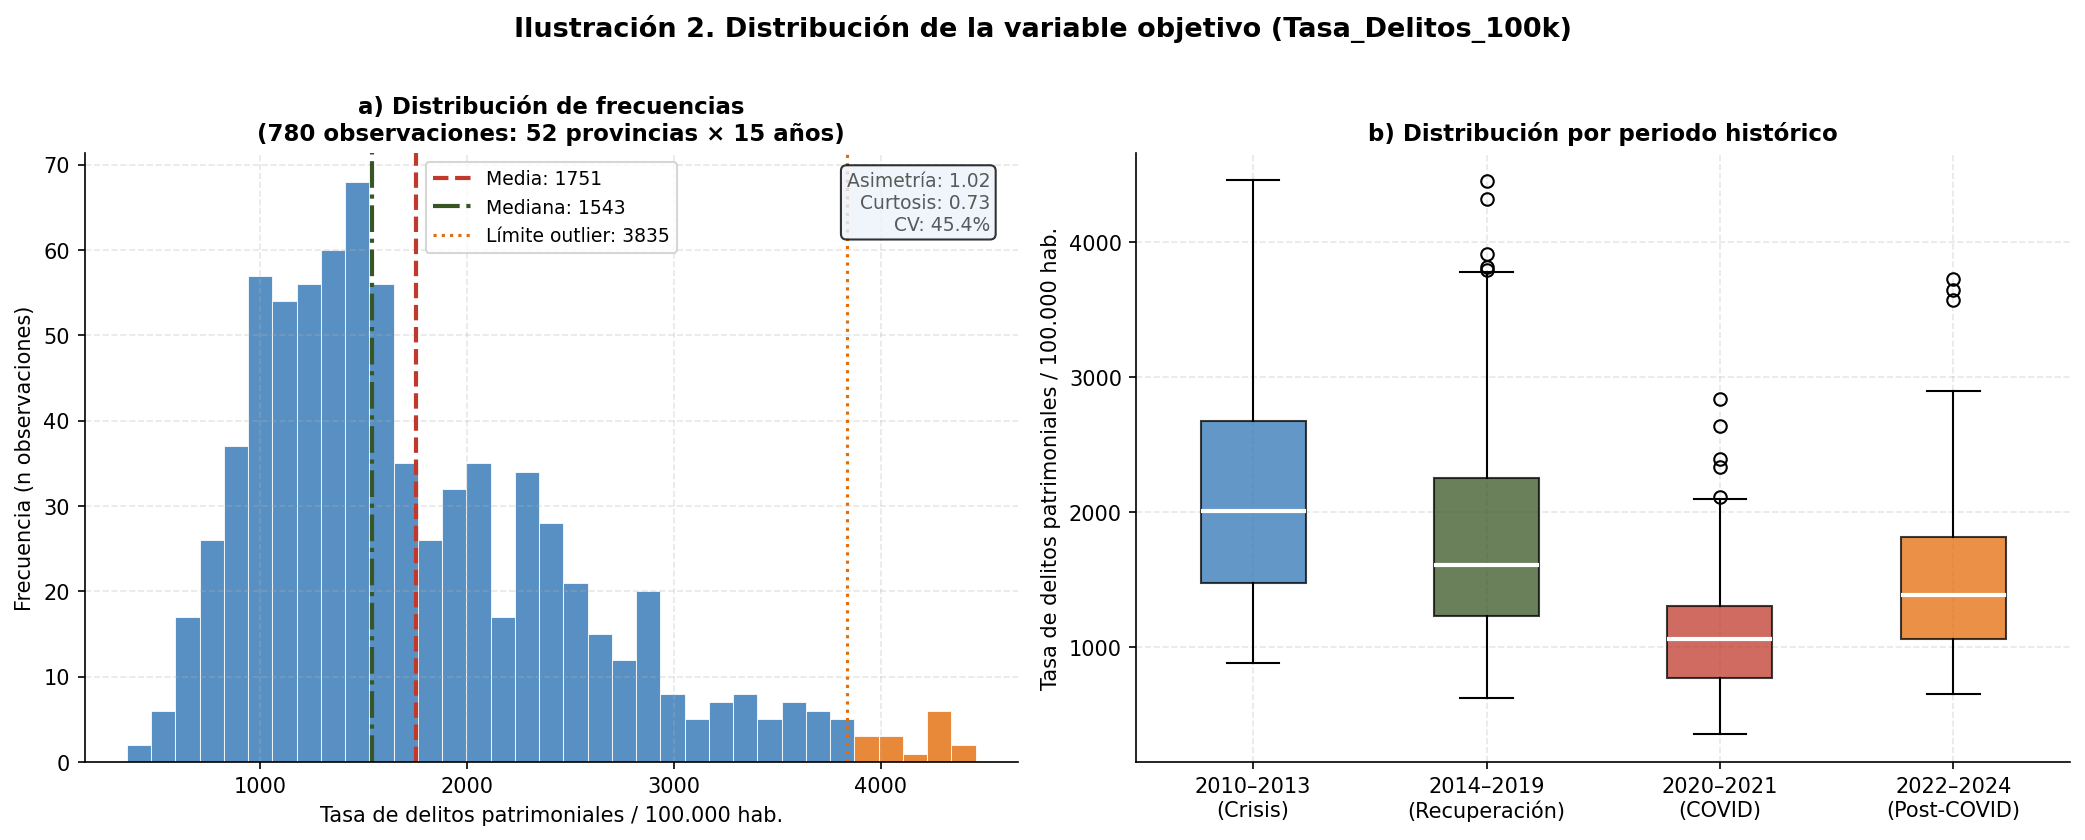

In [16]:
# ==============================================================================
# FIG 4 — DISTRIBUCIÓN DE LA TASA DE DELITOS (histograma + boxplot)
# ==============================================================================
print("Fig 4 — Distribución de la tasa de delitos")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Histograma
ax1 = axes[0]
n, bins, patches = ax1.hist(master['Tasa_Delitos_100k'], bins=35, color=C_AZUL,
                              alpha=0.8, edgecolor='white', linewidth=0.5)
# Colorear outliers
q75, q25 = np.percentile(master['Tasa_Delitos_100k'], [75, 25])
iqr = q75 - q25
upper_fence = q75 + 1.5 * iqr
for patch, left in zip(patches, bins[:-1]):
    if left > upper_fence:
        patch.set_facecolor(C_NARANJA)

ax1.axvline(master['Tasa_Delitos_100k'].mean(), color=C_ROJO, linestyle='--',
            linewidth=2, label=f"Media: {master['Tasa_Delitos_100k'].mean():.0f}")
ax1.axvline(master['Tasa_Delitos_100k'].median(), color=C_VERDE, linestyle='-.',
            linewidth=2, label=f"Mediana: {master['Tasa_Delitos_100k'].median():.0f}")
ax1.axvline(upper_fence, color=C_NARANJA, linestyle=':',
            linewidth=1.5, label=f"Límite outlier: {upper_fence:.0f}")
ax1.set_xlabel('Tasa de delitos patrimoniales / 100.000 hab.', fontsize=10)
ax1.set_ylabel('Frecuencia (n observaciones)', fontsize=10)
ax1.set_title('a) Distribución de frecuencias\n(780 observaciones: 52 provincias × 15 años)', fontsize=11)
ax1.legend(fontsize=9)

# Estadísticos en texto
stats_text = (f"Asimetría: {master['Tasa_Delitos_100k'].skew():.2f}\n"
              f"Curtosis: {master['Tasa_Delitos_100k'].kurt():.2f}\n"
              f"CV: {master['Tasa_Delitos_100k'].std()/master['Tasa_Delitos_100k'].mean()*100:.1f}%")
ax1.text(0.97, 0.97, stats_text, transform=ax1.transAxes,
         va='top', ha='right', fontsize=9, color=C_GRIS,
         bbox=dict(boxstyle='round', facecolor='#EBF3FB', alpha=0.8))

# Boxplot por tramos de año
ax2 = axes[1]
periodos = {
    '2010–2013\n(Crisis)': master[master['Año'].between(2010, 2013)]['Tasa_Delitos_100k'],
    '2014–2019\n(Recuperación)': master[master['Año'].between(2014, 2019)]['Tasa_Delitos_100k'],
    '2020–2021\n(COVID)': master[master['Año'].between(2020, 2021)]['Tasa_Delitos_100k'],
    '2022–2024\n(Post-COVID)': master[master['Año'].between(2022, 2024)]['Tasa_Delitos_100k'],
}
bp = ax2.boxplot(list(periodos.values()), labels=list(periodos.keys()),
                 patch_artist=True, notch=False,
                 medianprops=dict(color='white', linewidth=2))

colores_bp = [C_AZUL, C_VERDE, C_ROJO, C_NARANJA]
for patch, color in zip(bp['boxes'], colores_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax2.set_ylabel('Tasa de delitos patrimoniales / 100.000 hab.', fontsize=10)
ax2.set_title('b) Distribución por periodo histórico', fontsize=11)

plt.suptitle('Ilustración 2. Distribución de la variable objetivo (Tasa_Delitos_100k)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('./figuras/fig4_distribucion_tasa_delitos.png')


Fig 5 — Composición por tipología


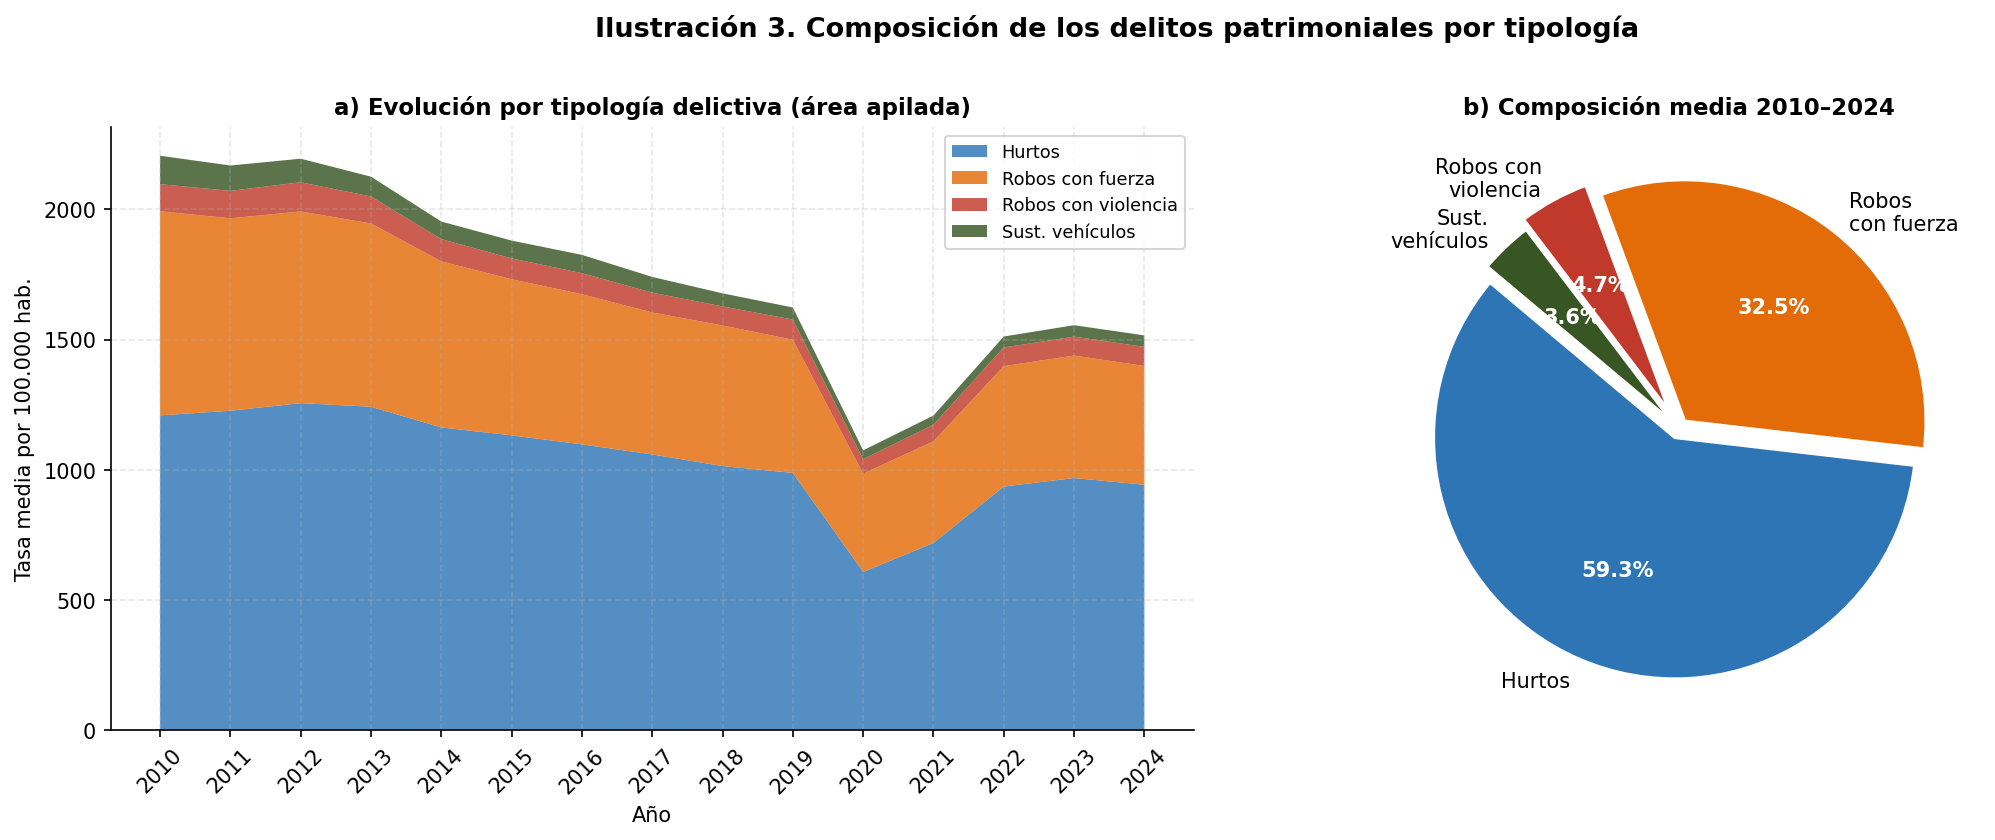

In [17]:
# ==============================================================================
# FIG 5 — COMPOSICIÓN DE DELITOS POR TIPOLOGÍA (área apilada)
# ==============================================================================
print("Fig 5 — Composición por tipología")

comp = master.groupby('Año')[['Hurtos_100k', 'Robos_Fuerza_100k',
                           'Robos_Violencia_100k', 'Sustraccion_Vehiculos_100k']].mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Área apilada
ax1 = axes[0]
ax1.stackplot(comp.index,
              comp['Hurtos_100k'],
              comp['Robos_Fuerza_100k'],
              comp['Robos_Violencia_100k'],
              comp['Sustraccion_Vehiculos_100k'],
              labels=['Hurtos', 'Robos con fuerza', 'Robos con violencia', 'Sust. vehículos'],
              colors=[C_AZUL, C_NARANJA, C_ROJO, C_VERDE], alpha=0.82)
ax1.set_xlabel('Año', fontsize=10)
ax1.set_ylabel('Tasa media por 100.000 hab.', fontsize=10)
ax1.set_title('a) Evolución por tipología delictiva (área apilada)', fontsize=11)
ax1.legend(loc='upper right', fontsize=8.5)
ax1.set_xticks(comp.index)
ax1.set_xticklabels(comp.index, rotation=45)

# Gráfico de tarta (media del periodo completo)
ax2 = axes[1]
medias_tipo = comp.mean()
labels_pie = ['Hurtos', 'Robos\ncon fuerza', 'Robos con\nviolencia', 'Sust.\nvehículos']
explode = (0.04, 0.04, 0.08, 0.04)
wedges, texts, autotexts = ax2.pie(
    medias_tipo.values,
    labels=labels_pie,
    autopct='%1.1f%%',
    colors=[C_AZUL, C_NARANJA, C_ROJO, C_VERDE],
    explode=explode,
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
    at.set_color('white')
ax2.set_title('b) Composición media 2010–2024', fontsize=11)

plt.suptitle('Ilustración 3. Composición de los delitos patrimoniales por tipología',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('./figuras/fig5_composicion_tipologias.png')


Fig 6 — Heatmap de correlaciones


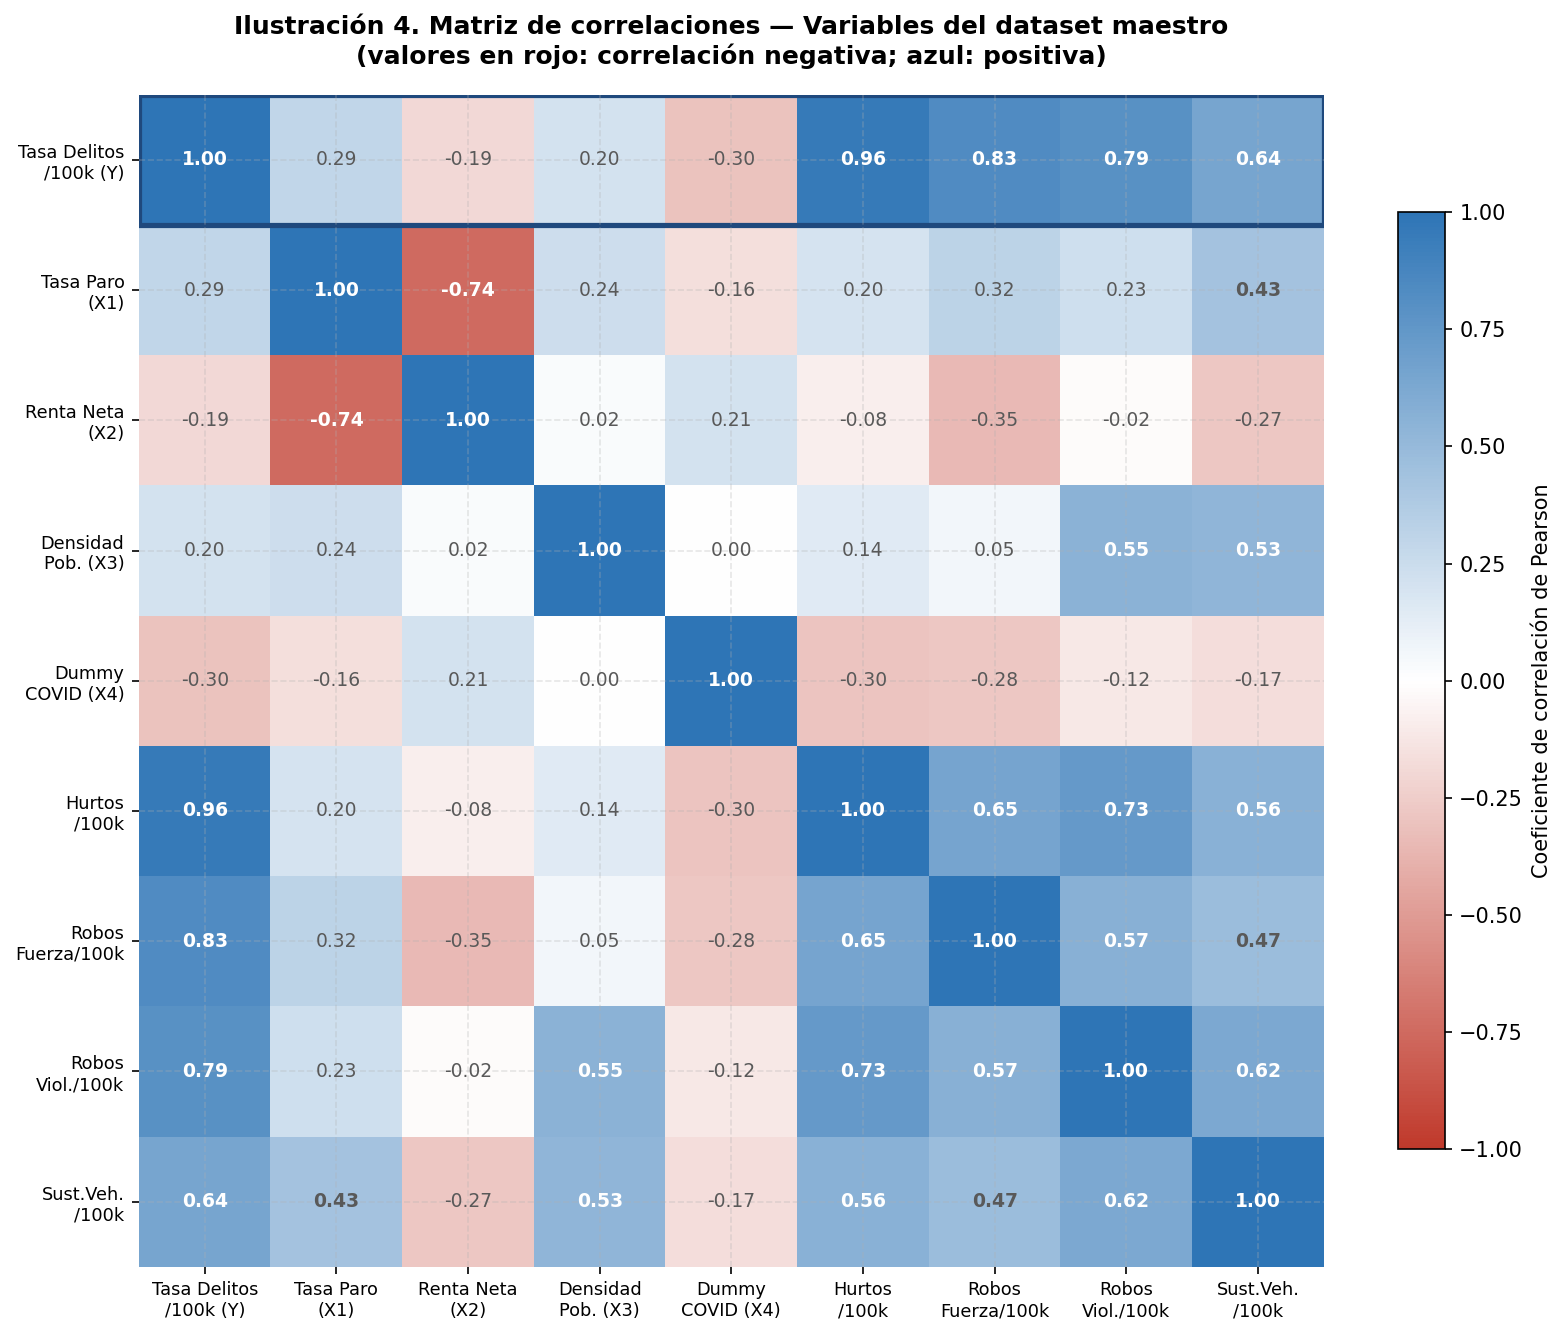

In [18]:
# ==============================================================================
# FIG 6 — HEATMAP DE CORRELACIONES
# ==============================================================================
print("Fig 6 — Heatmap de correlaciones")

vars_corr = ['Tasa_Delitos_100k', 'Tasa_Paro', 'Renta_Neta_Media',
             'Densidad_Poblacion', 'Dummy_COVID',
             'Hurtos_100k', 'Robos_Fuerza_100k', 'Robos_Violencia_100k',
             'Sustraccion_Vehiculos_100k']

labels_corr = ['Tasa Delitos\n/100k (Y)', 'Tasa Paro\n(X1)', 'Renta Neta\n(X2)',
               'Densidad\nPob. (X3)', 'Dummy\nCOVID (X4)',
               'Hurtos\n/100k', 'Robos\nFuerza/100k', 'Robos\nViol./100k',
               'Sust.Veh.\n/100k']

corr = master[vars_corr].corr()

cmap = LinearSegmentedColormap.from_list('ufv',
    [(0, C_ROJO), (0.5, 'white'), (1, C_AZUL)])

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr.values, cmap=cmap, vmin=-1, vmax=1, aspect='auto')

ax.set_xticks(range(len(labels_corr)))
ax.set_yticks(range(len(labels_corr)))
ax.set_xticklabels(labels_corr, fontsize=8.5)
ax.set_yticklabels(labels_corr, fontsize=8.5)

for i in range(len(vars_corr)):
    for j in range(len(vars_corr)):
        val = corr.values[i, j]
        color = 'white' if abs(val) > 0.5 else C_GRIS
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=9, color=color,
                fontweight='bold' if abs(val) > 0.4 else 'normal')

# Resaltar la primera fila/columna (variable objetivo Y)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.colorbar(im, ax=ax, shrink=0.8, label='Coeficiente de correlación de Pearson')
ax.set_title('Ilustración 4. Matriz de correlaciones — Variables del dataset maestro\n'
             '(valores en rojo: correlación negativa; azul: positiva)',
             fontsize=12, pad=15)

# Recuadro destacando la fila Y
rect = plt.Rectangle((-0.5, -0.5), len(vars_corr), 1,
                      linewidth=2.5, edgecolor=C_AZUL_OSC,
                      facecolor='none', linestyle='-')
ax.add_patch(rect)

plt.tight_layout()
plt.savefig('./figuras/fig6_heatmap_correlaciones.png')


Fig 7 — Scatter matrix Y vs. predictores


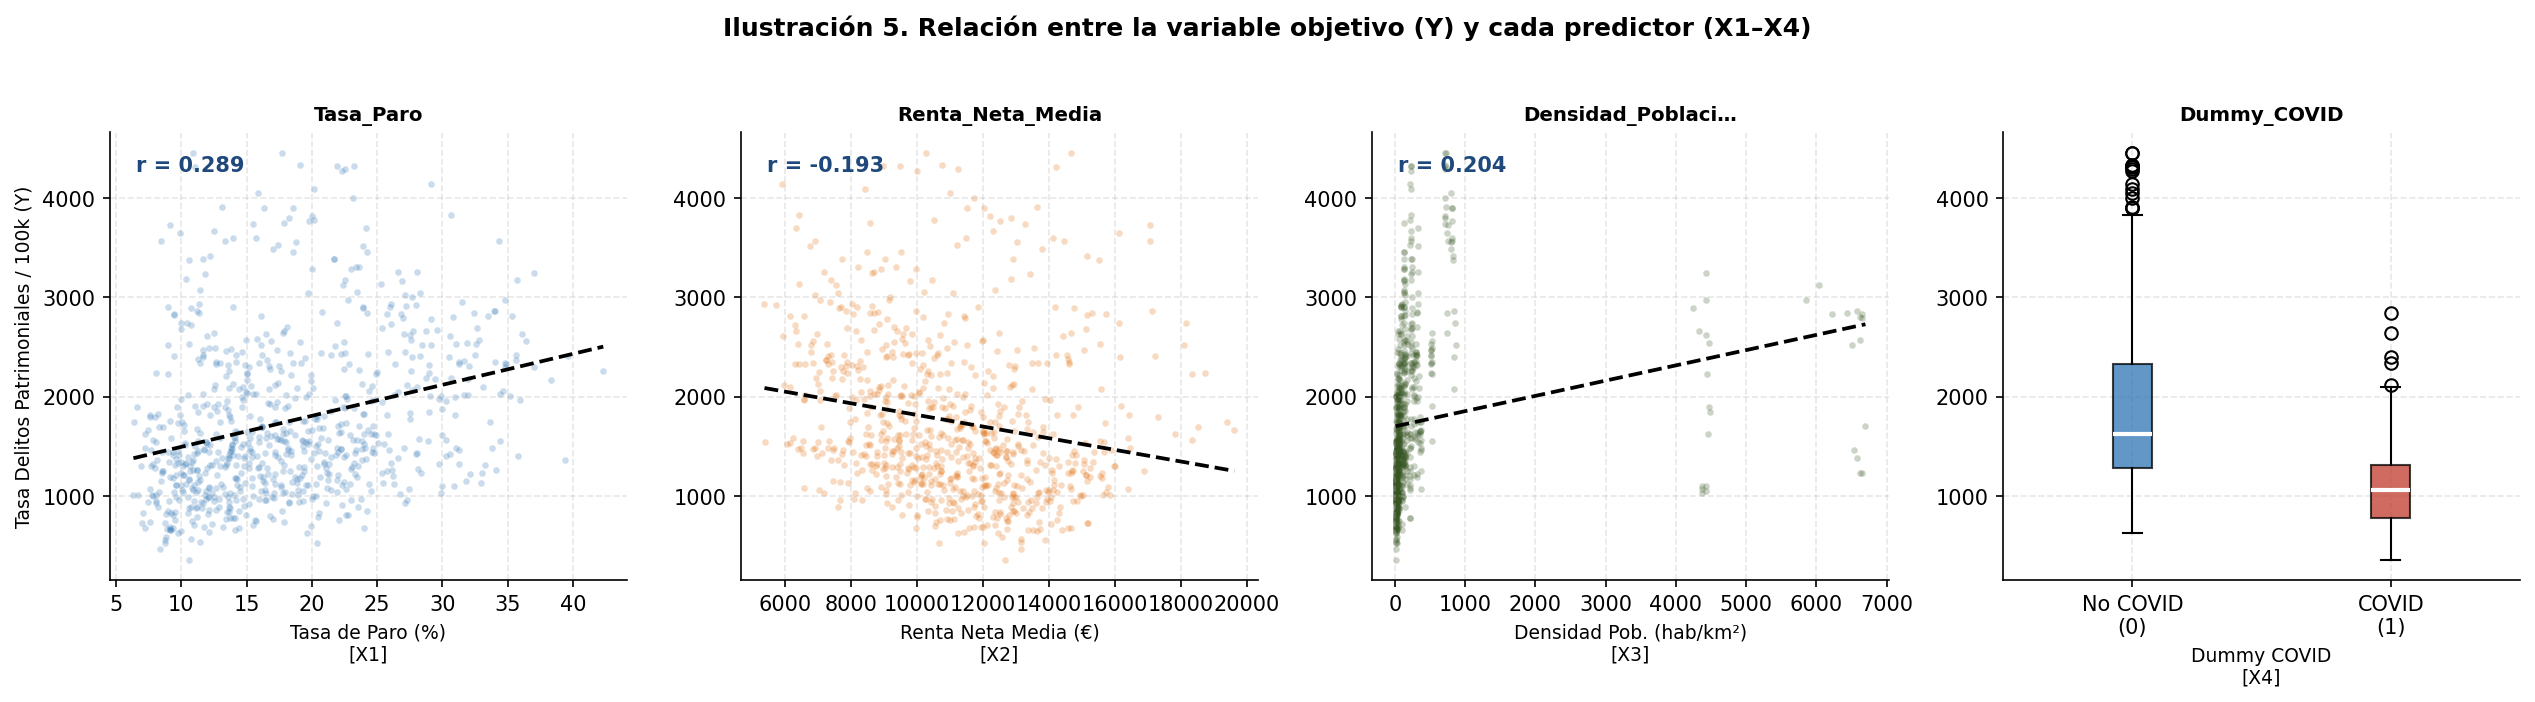

In [19]:
# ==============================================================================
# FIG 7 — SCATTER MATRIX: Y vs. predictores
# ==============================================================================
print("Fig 7 — Scatter matrix Y vs. predictores")

fig, axes = plt.subplots(1, 4, figsize=(17, 4.5))

predictores = [
    ('Tasa_Paro', 'Tasa de Paro (%)\n[X1]', C_AZUL),
    ('Renta_Neta_Media', 'Renta Neta Media (€)\n[X2]', C_NARANJA),
    ('Densidad_Poblacion', 'Densidad Pob. (hab/km²)\n[X3]', C_VERDE),
    ('Dummy_COVID', 'Dummy COVID\n[X4]', C_ROJO),
]

for ax, (xcol, xlabel, color) in zip(axes, predictores):
    covid_mask = master['Dummy_COVID'] == 1

    if xcol == 'Dummy_COVID':
        # Boxplot para variable dummy
        bp = ax.boxplot([master[~covid_mask]['Tasa_Delitos_100k'].values,
                         master[covid_mask]['Tasa_Delitos_100k'].values],
                        labels=['No COVID\n(0)', 'COVID\n(1)'],
                        patch_artist=True,
                        medianprops=dict(color='white', linewidth=2))
        bp['boxes'][0].set_facecolor(C_AZUL); bp['boxes'][0].set_alpha(0.75)
        bp['boxes'][1].set_facecolor(C_ROJO); bp['boxes'][1].set_alpha(0.75)
        ax.set_ylabel('')
    else:
        ax.scatter(master[xcol], master['Tasa_Delitos_100k'],
                   alpha=0.25, s=10, color=color, linewidths=0)
        # Línea de tendencia
        z = np.polyfit(master[xcol].dropna(), master.loc[master[xcol].notna(), 'Tasa_Delitos_100k'], 1)
        p = np.poly1d(z)
        xline = np.linspace(master[xcol].min(), master[xcol].max(), 100)
        ax.plot(xline, p(xline), color='black', linewidth=1.8, linestyle='--')
        # Correlación de Pearson
        r = master[[xcol, 'Tasa_Delitos_100k']].corr().iloc[0, 1]
        ax.text(0.05, 0.95, f'r = {r:.3f}', transform=ax.transAxes,
                va='top', fontsize=10, fontweight='bold', color=C_AZUL_OSC)

    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_title(f'{xcol[:16]}…' if len(xcol) > 16 else xcol, fontsize=9.5)

axes[0].set_ylabel('Tasa Delitos Patrimoniales / 100k (Y)', fontsize=9)

plt.suptitle('Ilustración 5. Relación entre la variable objetivo (Y) y cada predictor (X1–X4)',
             fontsize=12, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('./figuras/fig7_scatter_y_vs_predictores.png')


Fig 8 — Análisis de outliers


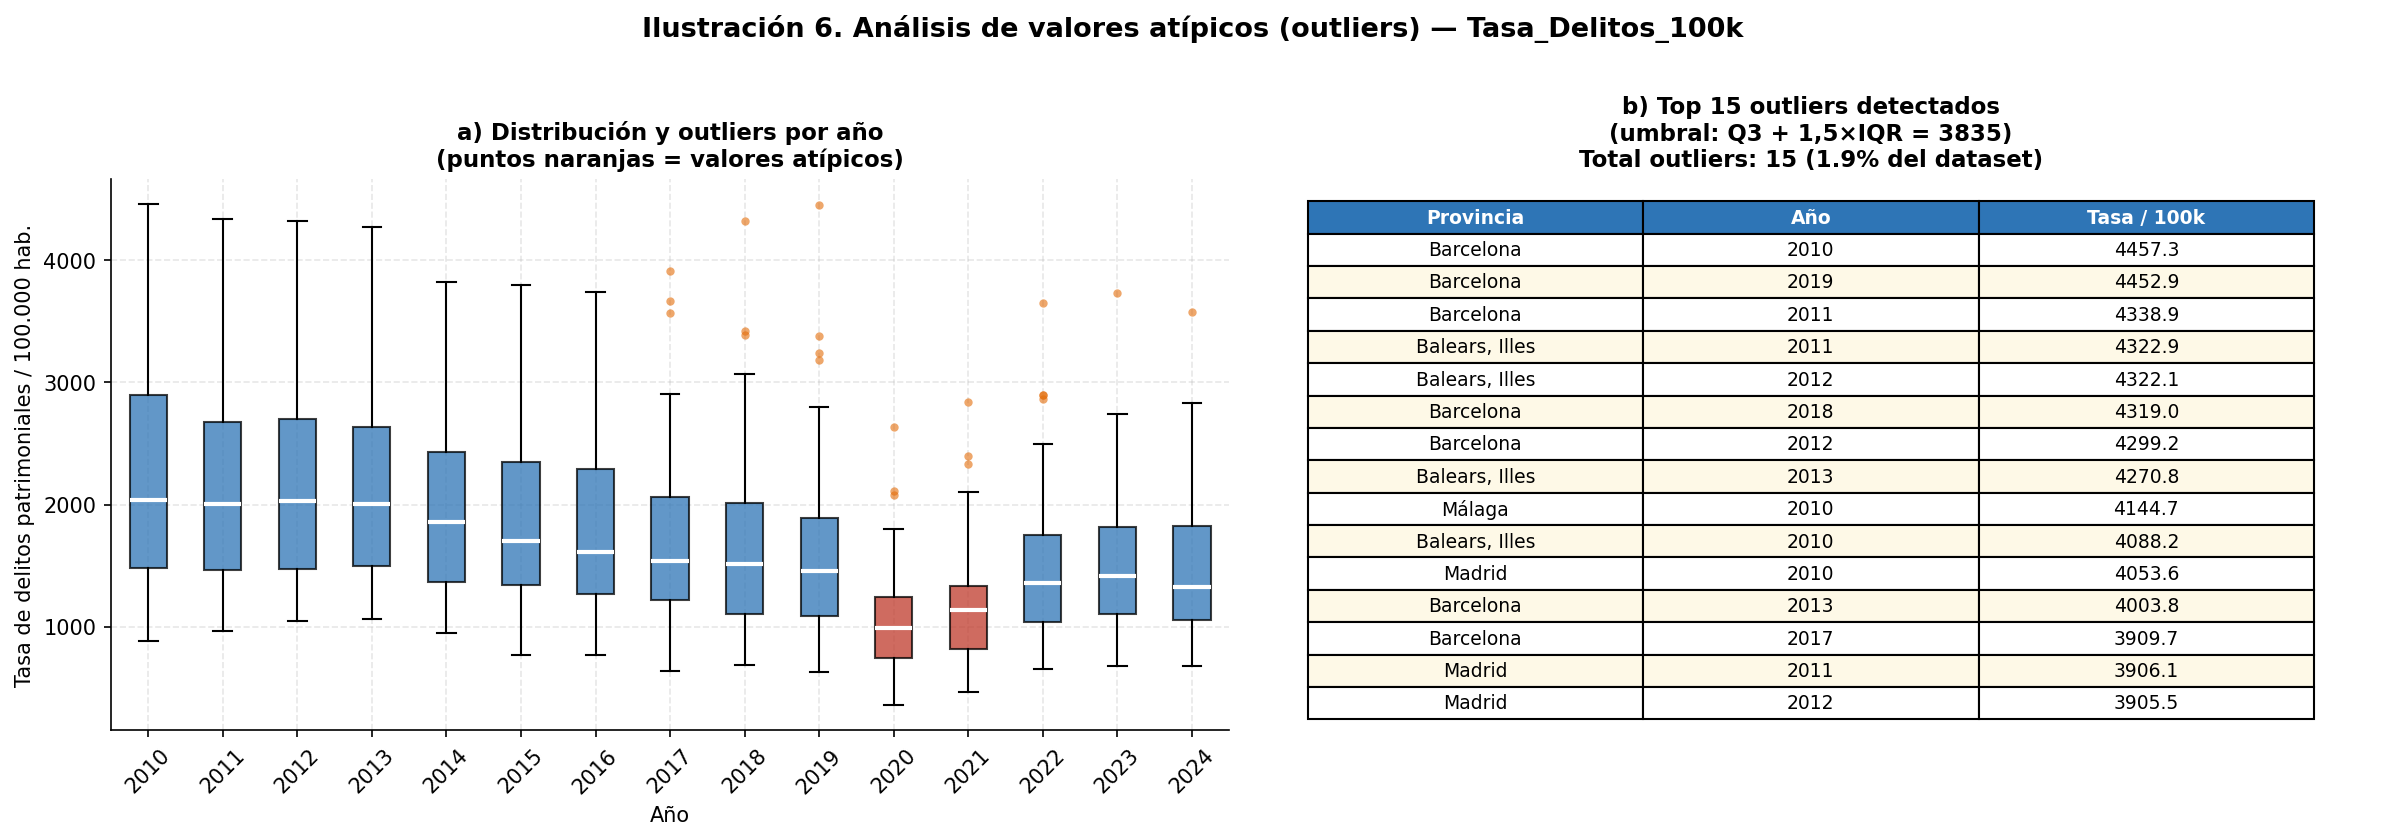

In [20]:
# ==============================================================================
# FIG 8 — ANÁLISIS DE OUTLIERS (boxplot por año)
# ==============================================================================
print("Fig 8 — Análisis de outliers")

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# Boxplot por año
ax1 = axes[0]
años = sorted(master['Año'].unique())
data_por_año = [master[master['Año'] == y]['Tasa_Delitos_100k'].values for y in años]

bp = ax1.boxplot(data_por_año, labels=[str(y) for y in años],
                 patch_artist=True,
                 medianprops=dict(color='white', linewidth=2),
                 flierprops=dict(marker='o', markerfacecolor=C_NARANJA,
                                 markersize=4, alpha=0.6, markeredgewidth=0))

for i, (patch, yr) in enumerate(zip(bp['boxes'], años)):
    if yr in [2020, 2021]:
        patch.set_facecolor(C_ROJO)
    else:
        patch.set_facecolor(C_AZUL)
    patch.set_alpha(0.75)

ax1.set_xlabel('Año', fontsize=10)
ax1.set_ylabel('Tasa de delitos patrimoniales / 100.000 hab.', fontsize=10)
ax1.set_title('a) Distribución y outliers por año\n(puntos naranjas = valores atípicos)', fontsize=11)
ax1.tick_params(axis='x', rotation=45)

# Identificar outliers (1.5×IQR)
q1 = master['Tasa_Delitos_100k'].quantile(0.25)
q3 = master['Tasa_Delitos_100k'].quantile(0.75)
iqr = q3 - q1
outliers = master[master['Tasa_Delitos_100k'] > q3 + 1.5 * iqr][
    ['Provincia', 'Año', 'Tasa_Delitos_100k']].sort_values('Tasa_Delitos_100k', ascending=False)

# Top outliers — tabla
ax2 = axes[1]
ax2.axis('off')
top_out = outliers.head(15).copy()
top_out['Tasa_Delitos_100k'] = top_out['Tasa_Delitos_100k'].round(1)
top_out.columns = ['Provincia', 'Año', 'Tasa / 100k']

table = ax2.table(
    cellText=top_out.values,
    colLabels=top_out.columns,
    cellLoc='center',
    loc='center',
    bbox=[0.05, 0.02, 0.9, 0.94]
)
table.auto_set_font_size(False)
table.set_fontsize(9)
for j in range(3):
    table[0, j].set_facecolor(C_AZUL)
    table[0, j].set_text_props(color='white', fontweight='bold')
for i in range(1, len(top_out) + 1):
    for j in range(3):
        table[i, j].set_facecolor('#FEF9E7' if i % 2 == 0 else 'white')

ax2.set_title(f'b) Top 15 outliers detectados\n(umbral: Q3 + 1,5×IQR = {q3+1.5*iqr:.0f})\n'
              f'Total outliers: {len(outliers)} ({len(outliers)/len(master)*100:.1f}% del dataset)',
              fontsize=11)

plt.suptitle('Ilustración 6. Análisis de valores atípicos (outliers) — Tasa_Delitos_100k',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('./figuras/fig8_analisis_outliers.png')


Fig 9 — Datos reales vs. interpolados (renta)


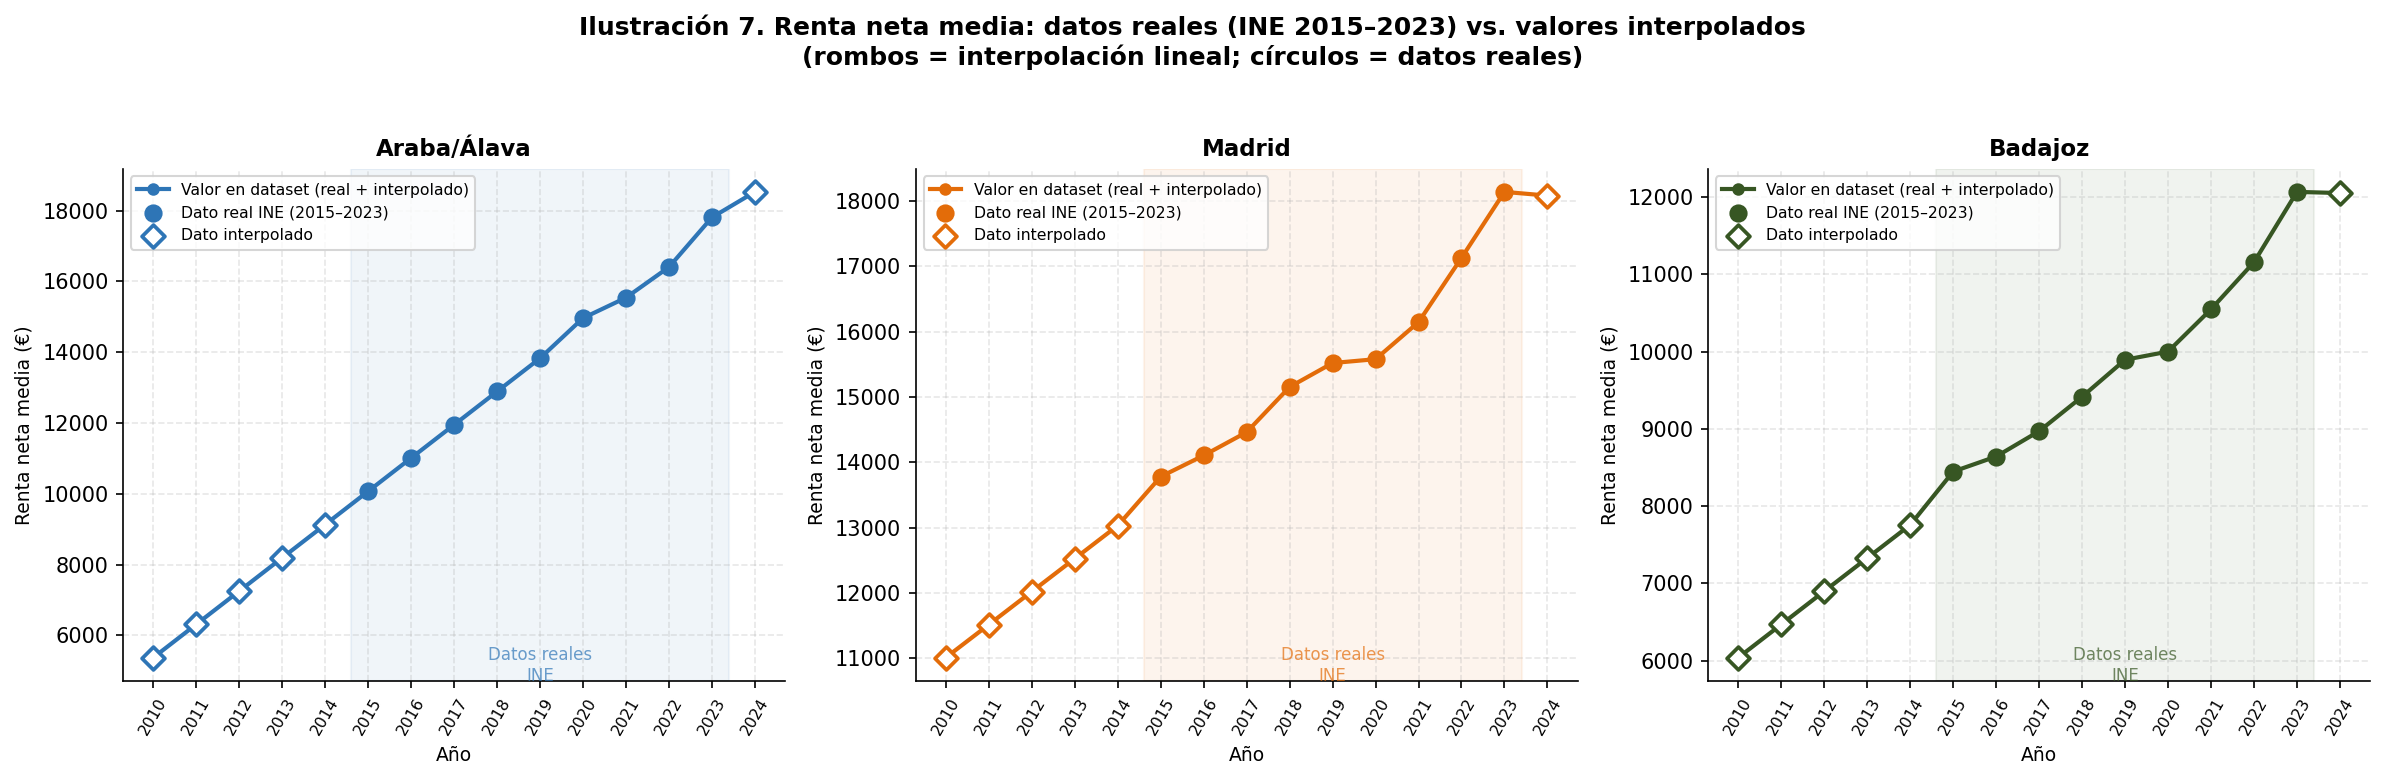

In [21]:
# ==============================================================================
# FIG 9 — EVOLUCIÓN RENTA: DATOS REALES VS. INTERPOLADOS
# ==============================================================================
print("Fig 9 — Datos reales vs. interpolados (renta)")

# Define constants for real income data range and foral provinces
RENTA_REAL_MIN = 2015
RENTA_REAL_MAX = 2023
PROV_FORALES = ['Araba/Álava', 'Gipuzkoa', 'Bizkaia', 'Navarra']

# Provincias representativas: una foral, una rica, una pobre
provs_ejemplo = ['Araba/Álava', 'Madrid', 'Extremadura']
# Extremadura puede no estar como tal — buscar alternativa
for alt in ['Extremadura', 'Badajoz', 'Cáceres', 'Jaén', 'Almería']:
    if alt in master['Provincia'].unique(): # Changed df to master
        provs_ejemplo[2] = alt
        break

colores_provs = [C_AZUL, C_NARANJA, C_VERDE]

fig, axes = plt.subplots(1, len(provs_ejemplo), figsize=(16, 5), sharey=False)

for ax, prov, color in zip(axes, provs_ejemplo, colores_provs):
    sub = master[master['Provincia'] == prov][['Año', 'Renta_Neta_Media']].sort_values('Año') # Changed df to master

    real_mask = sub['Año'].between(RENTA_REAL_MIN, RENTA_REAL_MAX)
    # Provincias forales tienen algunos huecos dentro también
    if prov in PROV_FORALES:
        real_mask = sub['Año'].between(RENTA_REAL_MIN, RENTA_REAL_MAX)

    ax.plot(sub['Año'], sub['Renta_Neta_Media'],
            color=color, linewidth=2, marker='o', markersize=5, zorder=3,
            label='Valor en dataset (real + interpolado)')

    ax.scatter(sub[real_mask]['Año'], sub[real_mask]['Renta_Neta_Media'],
               color=color, s=60, zorder=5, label='Dato real INE (2015–2023)')

    interp_mask = ~real_mask
    ax.scatter(sub[interp_mask]['Año'], sub[interp_mask]['Renta_Neta_Media'],
               color='white', edgecolors=color, s=60, linewidths=1.8,
               zorder=5, marker='D', label='Dato interpolado')

    ax.axvspan(RENTA_REAL_MIN - 0.4, RENTA_REAL_MAX + 0.4, alpha=0.07,
               color=color, zorder=0)
    ax.text((RENTA_REAL_MIN + RENTA_REAL_MAX) / 2, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else sub['Renta_Neta_Media'].min() * 0.92,
            'Datos reales\nINE', ha='center', fontsize=8, color=color, alpha=0.7)

    ax.set_title(f'{prov}', fontsize=11)
    ax.set_xlabel('Año', fontsize=9)
    ax.set_ylabel('Renta neta media (€)', fontsize=9)
    ax.set_xticks(sub['Año'].values)
    ax.set_xticklabels(sub['Año'].values, rotation=60, fontsize=7.5)
    ax.legend(fontsize=7.5, loc='upper left')

plt.suptitle('Ilustración 7. Renta neta media: datos reales (INE 2015–2023) vs. valores interpolados\n'
             '(rombos = interpolación lineal; círculos = datos reales)',
             fontsize=12, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('./figuras/fig9_renta_real_vs_interpolada.png')


Fig 10 — Ranking de provincias


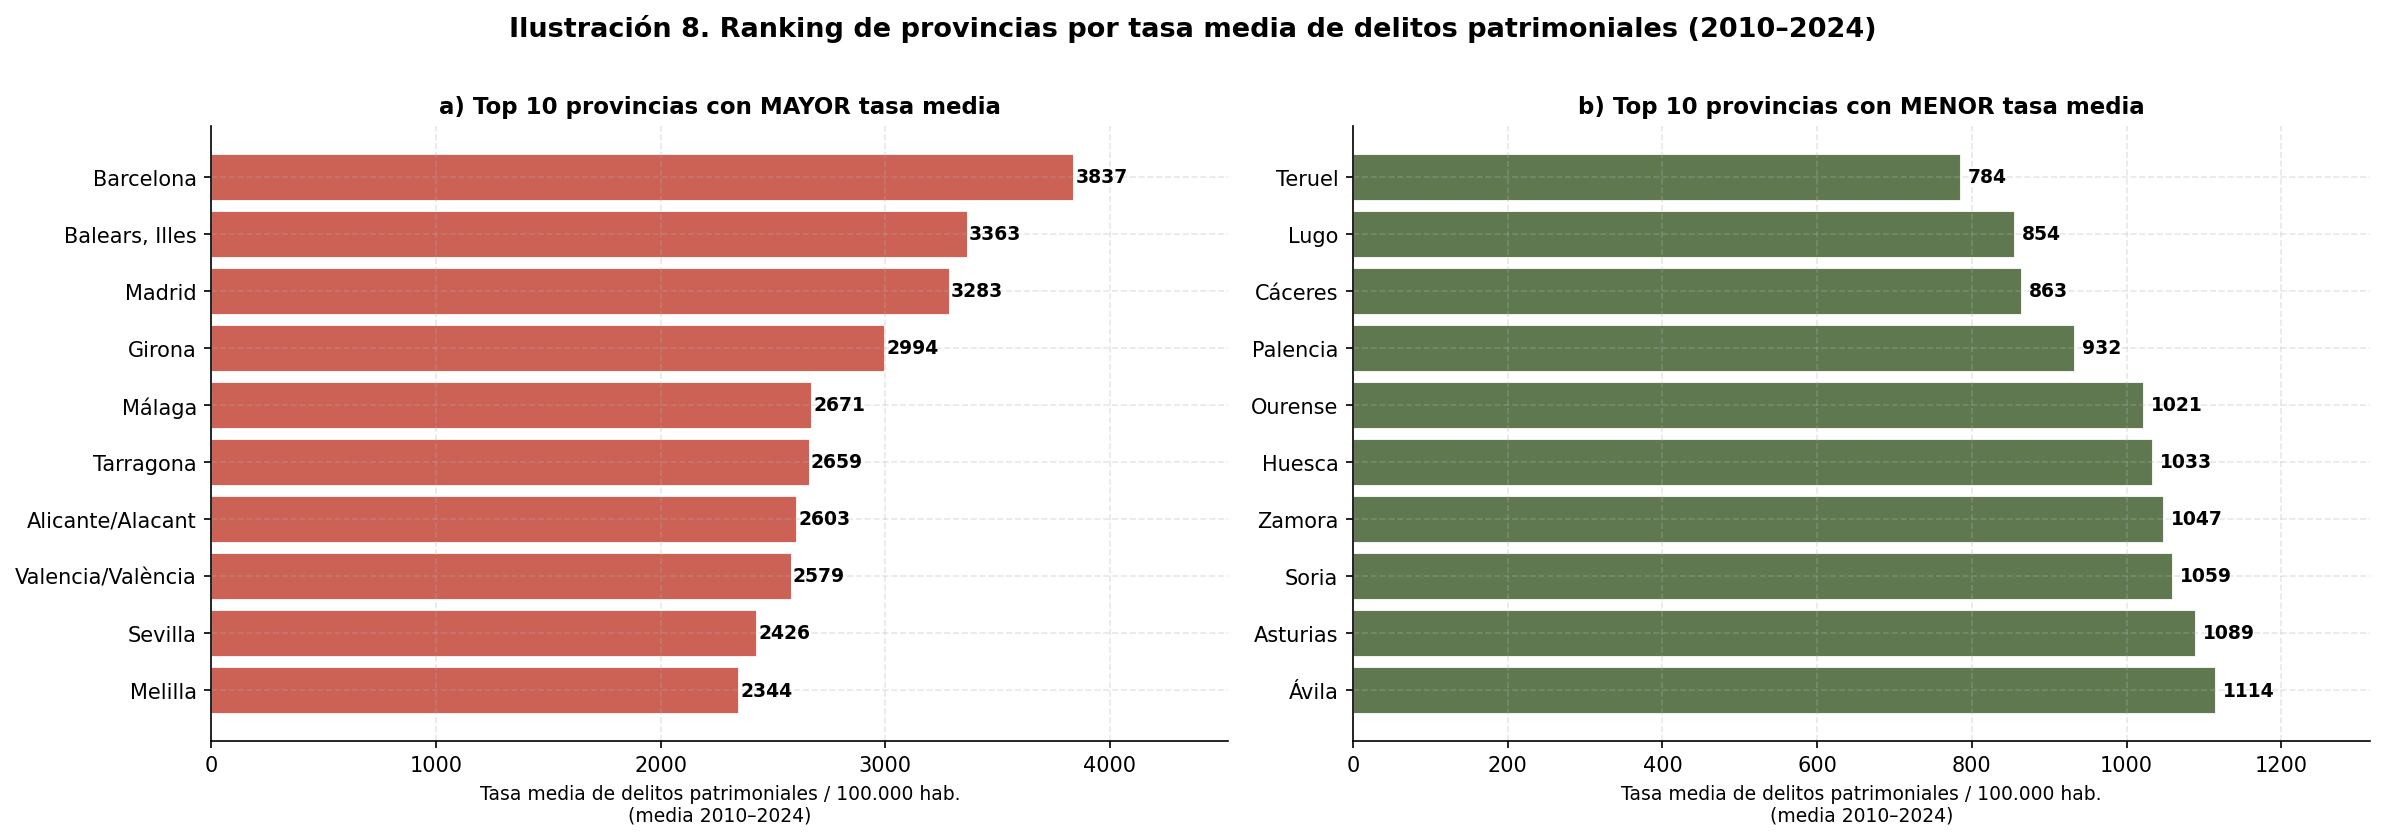

In [22]:
# ==============================================================================
# FIG 10 — TOP 10 / BOTTOM 10 PROVINCIAS
# ==============================================================================
print("Fig 10 — Ranking de provincias")

ranking = master.groupby('Provincia')['Tasa_Delitos_100k'].mean().sort_values(ascending=False)
top10 = ranking.head(10)
bot10 = ranking.tail(10).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

for ax, data, titulo, color in [
    (axes[0], top10, 'a) Top 10 provincias con MAYOR tasa media', C_ROJO),
    (axes[1], bot10, 'b) Top 10 provincias con MENOR tasa media', C_VERDE),
]:
    bars = ax.barh(data.index, data.values, color=color, alpha=0.8,
                   edgecolor='white', linewidth=0.5)
    ax.set_xlabel('Tasa media de delitos patrimoniales / 100.000 hab.\n(media 2010–2024)', fontsize=9)
    ax.set_title(titulo, fontsize=11)
    ax.invert_yaxis()
    for bar, val in zip(bars, data.values):
        ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
                f'{val:.0f}', va='center', ha='left', fontsize=9, fontweight='bold')
    ax.set_xlim(0, data.values.max() * 1.18)
    ax.spines['left'].set_visible(True)

plt.suptitle('Ilustración 8. Ranking de provincias por tasa media de delitos patrimoniales (2010–2024)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('./figuras/fig10_ranking_provincias.png')

Fig 11 — Efecto COVID


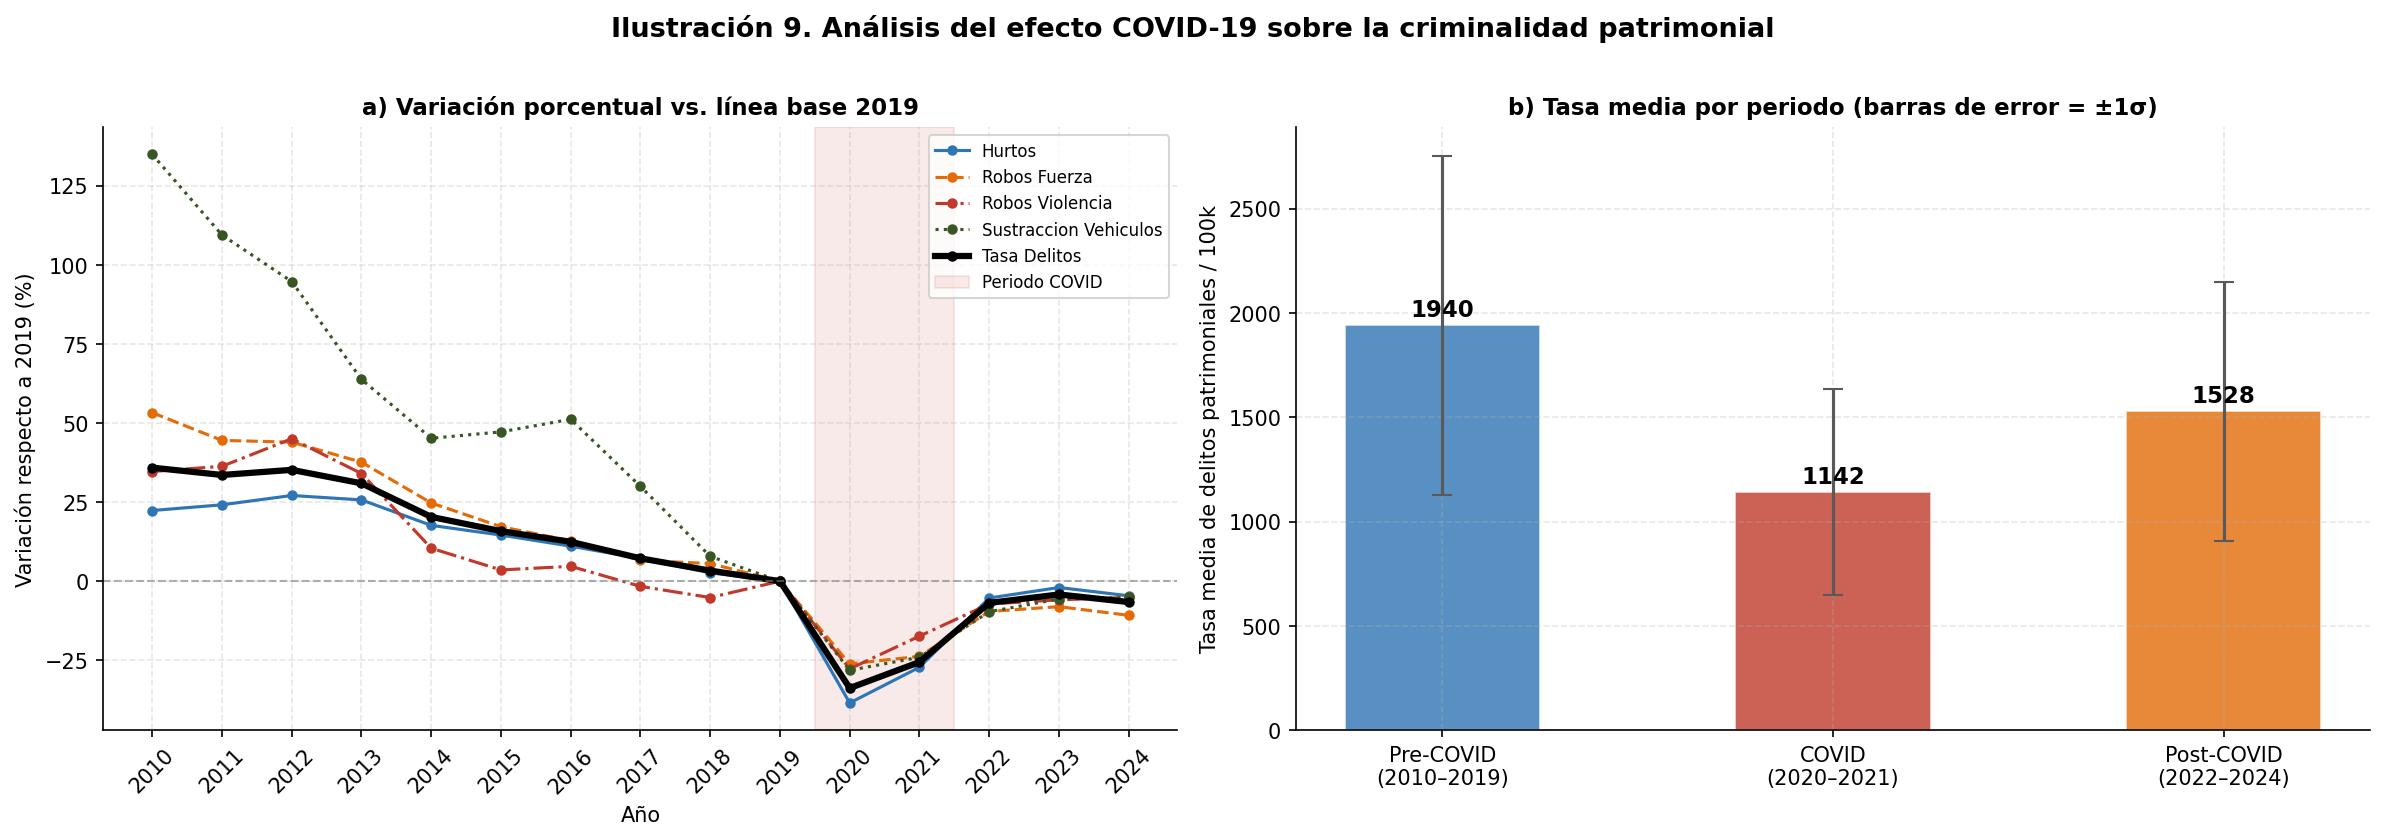

In [23]:
# ==============================================================================
# FIG 11 — EFECTO COVID: ANTES / DURANTE / DESPUÉS
# ==============================================================================
print("Fig 11 — Efecto COVID")

master['Periodo'] = pd.cut(master['Año'],
                        bins=[2009, 2019, 2021, 2024],
                        labels=['Pre-COVID\n(2010–2019)', 'COVID\n(2020–2021)', 'Post-COVID\n(2022–2024)'])

evol_tip = master.groupby(['Año'])[
    ['Hurtos_100k', 'Robos_Fuerza_100k', 'Robos_Violencia_100k',
     'Sustraccion_Vehiculos_100k', 'Tasa_Delitos_100k']].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# Variación porcentual respecto a 2019
base_2019 = evol_tip.loc[2019]
var_pct = ((evol_tip - base_2019) / base_2019 * 100)

ax1 = axes[0]
colores_lineas = [C_AZUL, C_NARANJA, C_ROJO, C_VERDE, 'black']
estilos = ['-', '--', '-.', ':', '-']
for col, color, ls in zip(var_pct.columns, colores_lineas, estilos):
    lw = 3 if col == 'Tasa_Delitos_100k' else 1.5
    ax1.plot(var_pct.index, var_pct[col], color=color, linewidth=lw,
             linestyle=ls, marker='o', markersize=4,
             label=col.replace('_100k', '').replace('_', ' '))

ax1.axhline(0, color='grey', linestyle='--', linewidth=1, alpha=0.6)
ax1.axvspan(2019.5, 2021.5, alpha=0.1, color=C_ROJO, label='Periodo COVID')
ax1.set_xlabel('Año', fontsize=10)
ax1.set_ylabel('Variación respecto a 2019 (%)', fontsize=10)
ax1.set_title('a) Variación porcentual vs. línea base 2019', fontsize=11)
ax1.legend(fontsize=8, loc='upper right')
ax1.set_xticks(var_pct.index)
ax1.set_xticklabels(var_pct.index, rotation=45)

# Comparación de medias por periodo
ax2 = axes[1]
medias_periodo = master.groupby('Periodo')['Tasa_Delitos_100k'].agg(['mean', 'std'])
bars = ax2.bar(medias_periodo.index, medias_periodo['mean'],
               color=[C_AZUL, C_ROJO, C_NARANJA], alpha=0.8,
               edgecolor='white', linewidth=0.8, width=0.5)
ax2.errorbar(medias_periodo.index, medias_periodo['mean'],
             yerr=medias_periodo['std'], fmt='none',
             color=C_GRIS, capsize=5, linewidth=1.5)

for bar, val in zip(bars, medias_periodo['mean']):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
             f'{val:.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax2.set_ylabel('Tasa media de delitos patrimoniales / 100k', fontsize=10)
ax2.set_title('b) Tasa media por periodo (barras de error = ±1σ)', fontsize=11)

plt.suptitle('Ilustración 9. Análisis del efecto COVID-19 sobre la criminalidad patrimonial',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('./figuras/fig11_efecto_covid.png')

Fig 12 — Heatmap provincia × año


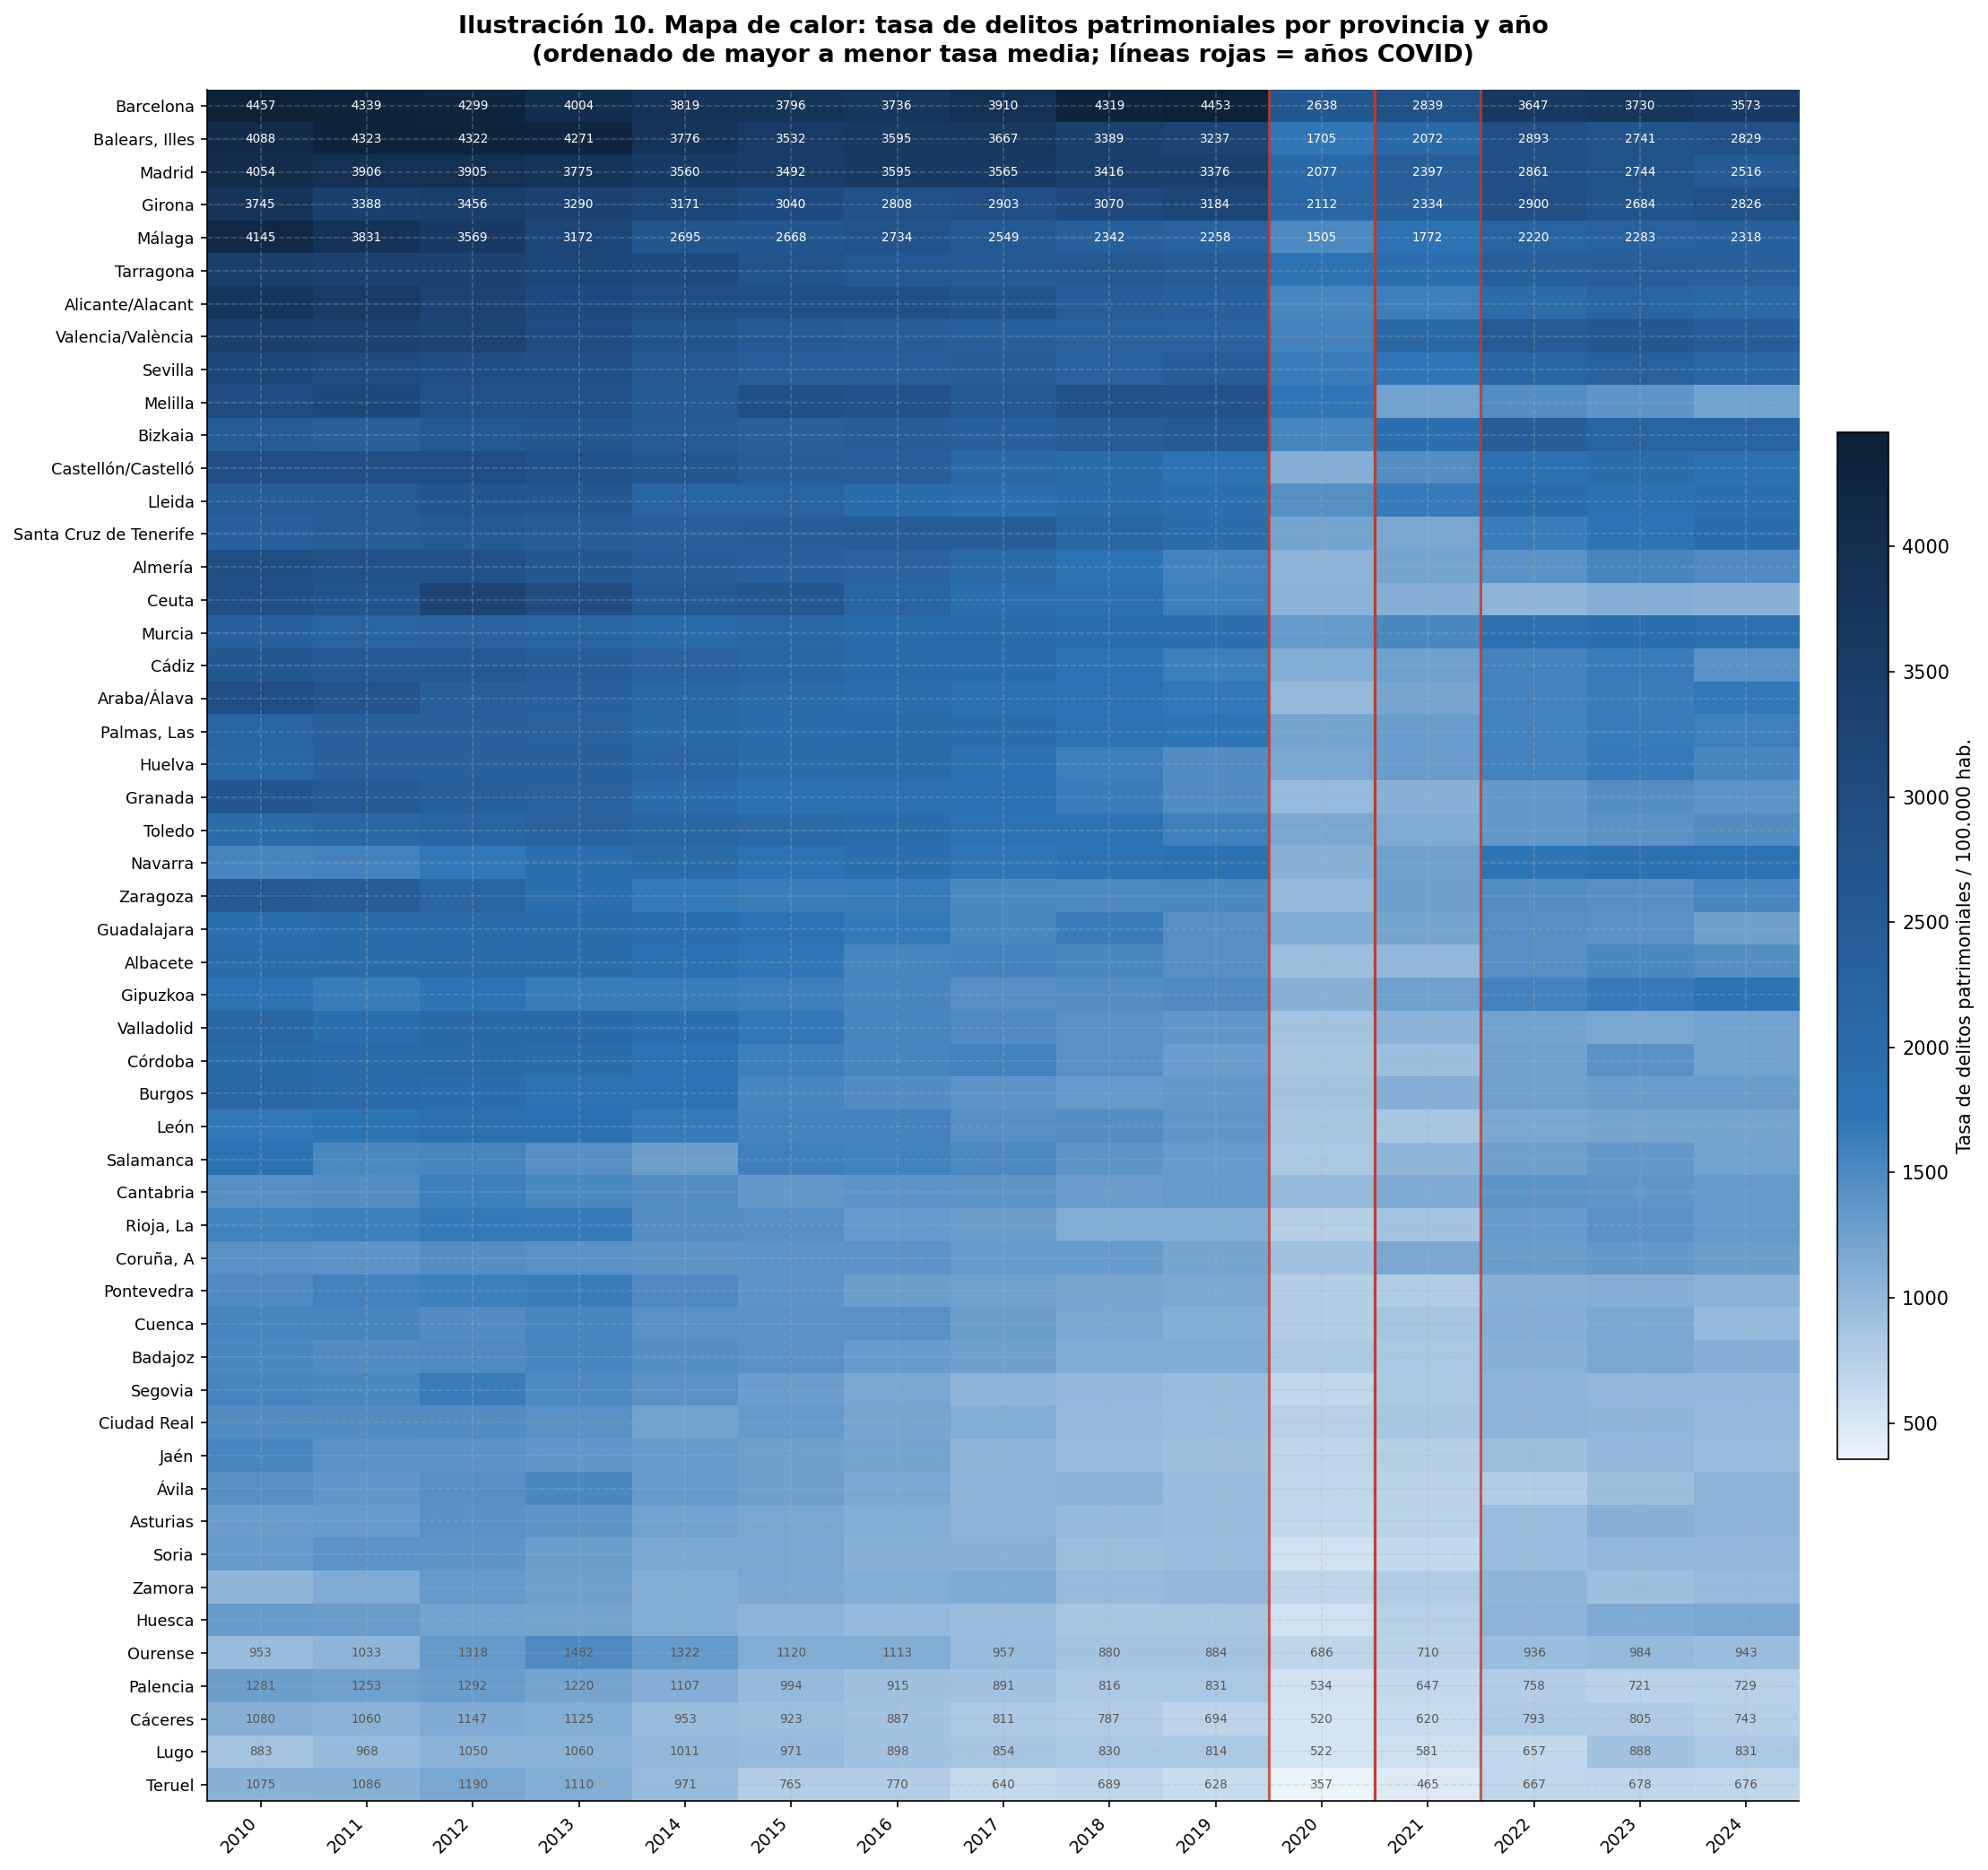

In [24]:
# ==============================================================================
# FIG 12 — HEATMAP PROVINCIA × AÑO (criminalidad patrimonial)
# ==============================================================================
print("Fig 12 — Heatmap provincia × año")

pivot = master.pivot_table(index='Provincia', columns='Año',
                        values='Tasa_Delitos_100k', aggfunc='mean')

# Ordenar provincias por tasa media descendente
orden = pivot.mean(axis=1).sort_values(ascending=False)
pivot = pivot.loc[orden.index]

cmap2 = LinearSegmentedColormap.from_list('delitos',
    ['#EBF3FB', '#2E75B6', '#1F497D', '#0D2137'])

fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(pivot.values, cmap=cmap2, aspect='auto')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=8.5)

# Añadir valores en las celdas para las provincias más extremas
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val) and (i < 5 or i >= len(pivot.index) - 5):
            ax.text(j, i, f'{val:.0f}', ha='center', va='center',
                    fontsize=6.5, color='white' if val > 1500 else C_GRIS)

# Líneas separadoras COVID
for yr_idx, yr in enumerate(pivot.columns):
    if yr in [2020, 2021]:
        ax.axvline(yr_idx - 0.5, color=C_ROJO, linewidth=1.5, alpha=0.8)
        ax.axvline(yr_idx + 0.5, color=C_ROJO, linewidth=1.5, alpha=0.8)

plt.colorbar(im, ax=ax, label='Tasa de delitos patrimoniales / 100.000 hab.',
             shrink=0.6, pad=0.02)

ax.set_title('Ilustración 10. Mapa de calor: tasa de delitos patrimoniales por provincia y año\n'
             '(ordenado de mayor a menor tasa media; líneas rojas = años COVID)',
             fontsize=13, pad=15)

plt.tight_layout()
plt.savefig('./figuras/fig12_heatmap_provincia_año.png')

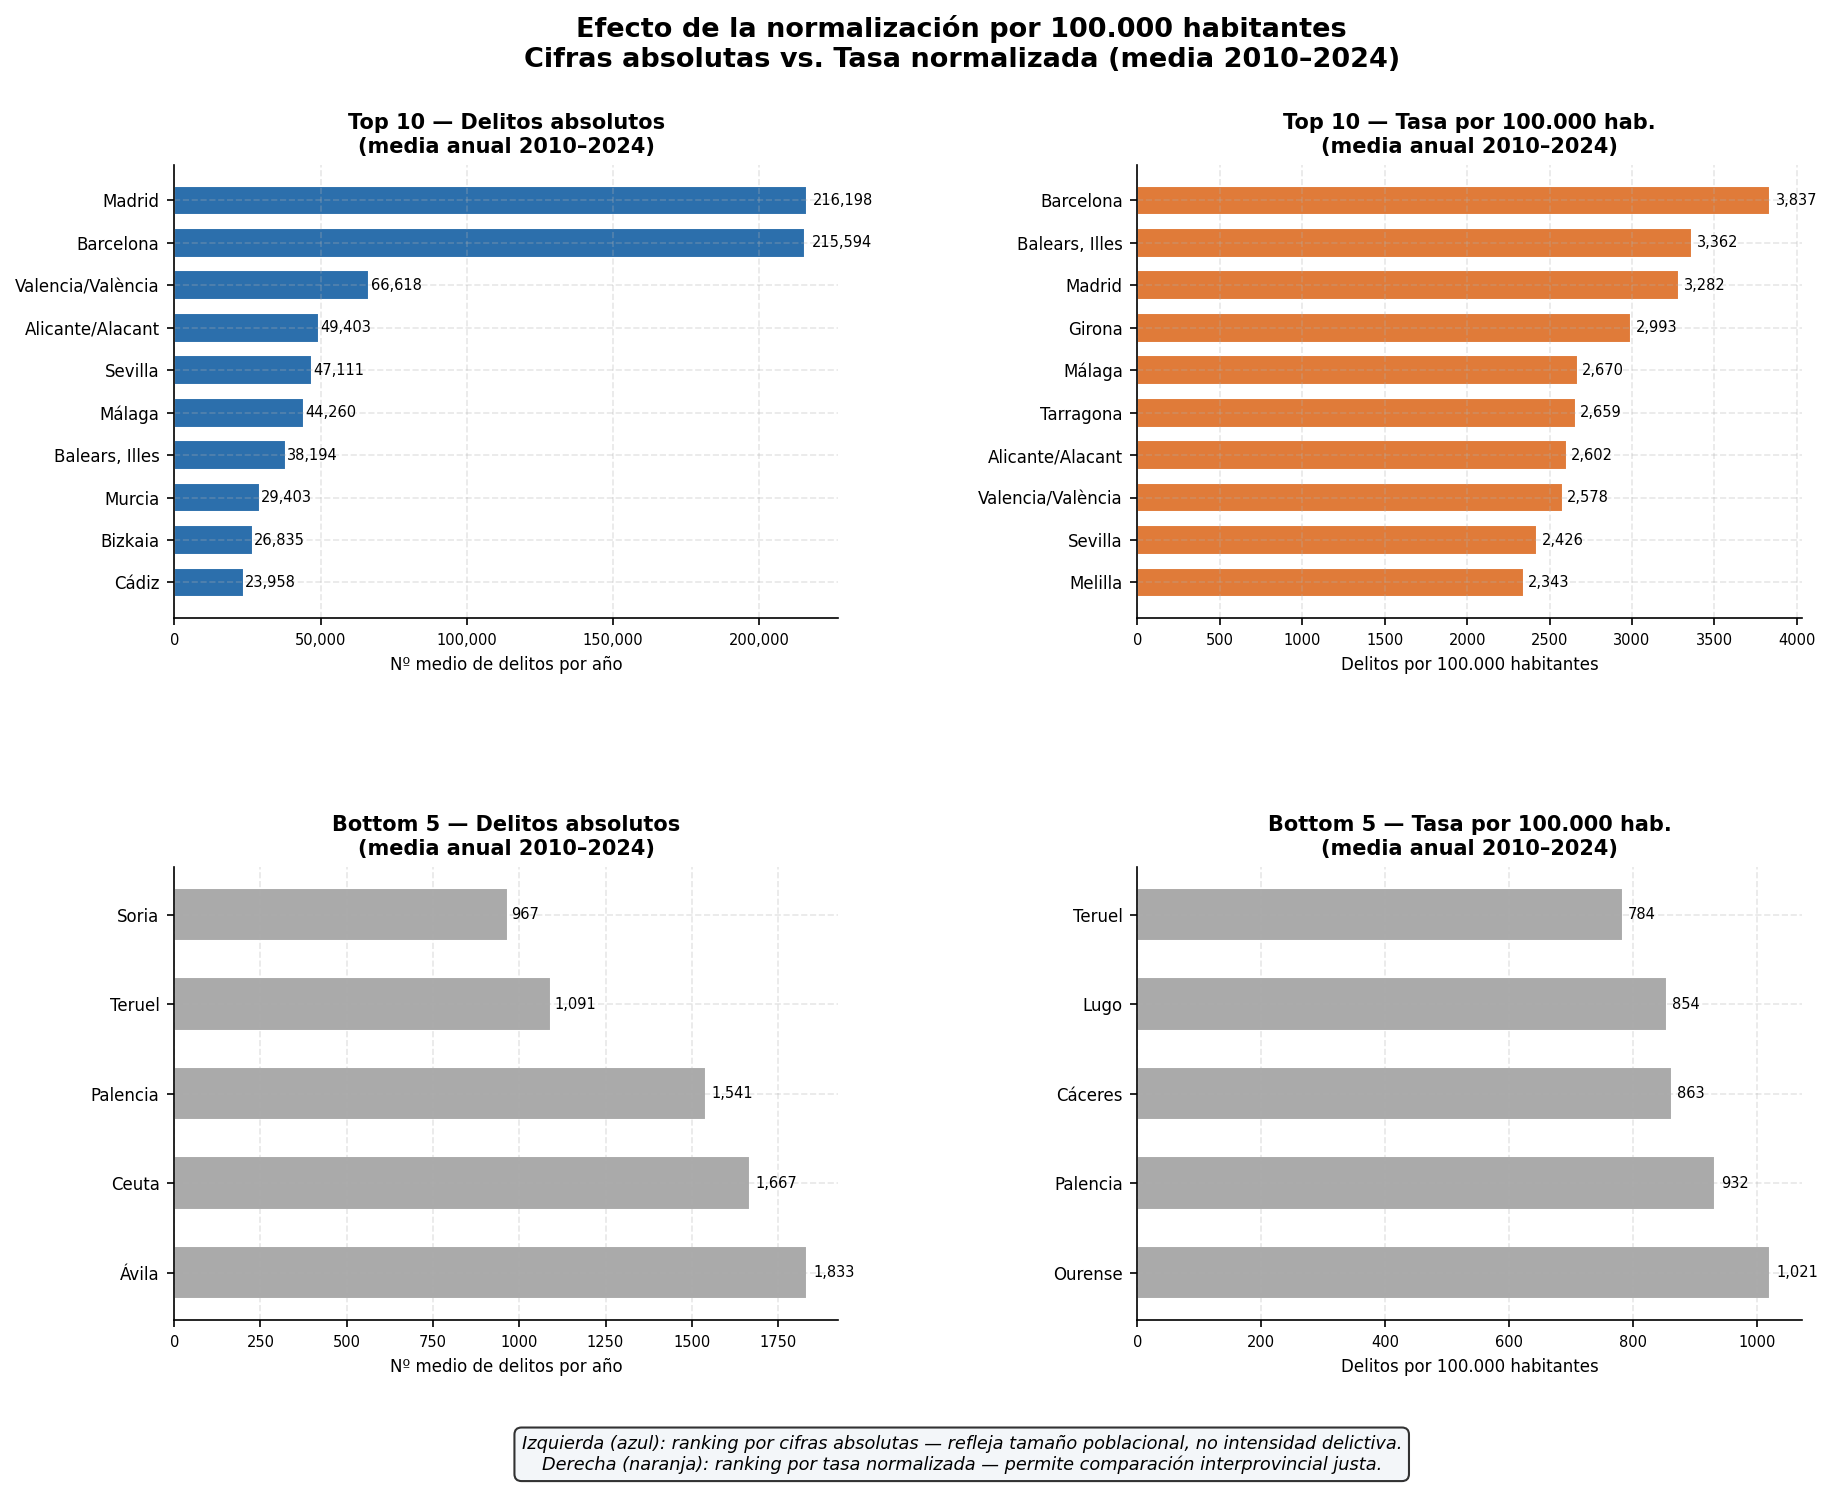

Figura guardada: ilustracion_normalizacion_antes_despues.png


In [25]:
# ============================================================
# SECCIÓN 4.5.8 — Visualización antes y después de la normalización
# ============================================================

df = pd.read_csv('base_datos_maestra.csv', encoding='utf-8-sig')

# --- Datos: media por provincia (2010-2024) ---
resumen = df.groupby('Provincia').agg(
    Delitos_Absolutos=('Delitos_Patrimoniales', 'mean'),
    Tasa_100k=('Tasa_Delitos_100k', 'mean')
).reset_index()

# Top 10 y Bottom 5 por delitos absolutos
top_abs   = resumen.nlargest(10, 'Delitos_Absolutos')
bot_abs   = resumen.nsmallest(5, 'Delitos_Absolutos')

# Top 10 y Bottom 5 por tasa normalizada
top_norm  = resumen.nlargest(10, 'Tasa_100k')
bot_norm  = resumen.nsmallest(5, 'Tasa_100k')

# ---- FIGURA: 4 barras horizontales ----------------------------
fig = plt.figure(figsize=(14, 10))
fig.suptitle(
    'Efecto de la normalización por 100.000 habitantes\n'
    'Cifras absolutas vs. Tasa normalizada (media 2010–2024)',
    fontsize=13, fontweight='bold', y=0.98
)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.55, wspace=0.45)

COLOR_ABS  = '#2C6FAC'   # azul oscuro → cifras absolutas
COLOR_NORM = '#E07B39'   # naranja      → tasa normalizada
COLOR_BOT  = '#AAAAAA'   # gris         → bottom

# ── Panel 1: Top 10 cifras absolutas ──────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
bars1 = ax1.barh(top_abs['Provincia'], top_abs['Delitos_Absolutos'],
                 color=COLOR_ABS, edgecolor='white', height=0.7)
ax1.set_title('Top 10 — Delitos absolutos\n(media anual 2010–2024)',
              fontsize=10, fontweight='bold')
ax1.set_xlabel('Nº medio de delitos por año', fontsize=8)
ax1.invert_yaxis()
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar in bars1:
    w = bar.get_width()
    ax1.text(w * 1.01, bar.get_y() + bar.get_height()/2,
             f'{int(w):,}', va='center', fontsize=7)
ax1.tick_params(axis='y', labelsize=8)
ax1.tick_params(axis='x', labelsize=7)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── Panel 2: Top 10 tasa normalizada ──────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
bars2 = ax2.barh(top_norm['Provincia'], top_norm['Tasa_100k'],
                 color=COLOR_NORM, edgecolor='white', height=0.7)
ax2.set_title('Top 10 — Tasa por 100.000 hab.\n(media anual 2010–2024)',
              fontsize=10, fontweight='bold')
ax2.set_xlabel('Delitos por 100.000 habitantes', fontsize=8)
ax2.invert_yaxis()
for bar in bars2:
    w = bar.get_width()
    ax2.text(w * 1.01, bar.get_y() + bar.get_height()/2,
             f'{int(w):,}', va='center', fontsize=7)
ax2.tick_params(axis='y', labelsize=8)
ax2.tick_params(axis='x', labelsize=7)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ── Panel 3: Bottom 5 cifras absolutas ────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
bars3 = ax3.barh(bot_abs['Provincia'], bot_abs['Delitos_Absolutos'],
                 color=COLOR_BOT, edgecolor='white', height=0.6)
ax3.set_title('Bottom 5 — Delitos absolutos\n(media anual 2010–2024)',
              fontsize=10, fontweight='bold')
ax3.set_xlabel('Nº medio de delitos por año', fontsize=8)
ax3.invert_yaxis()
for bar in bars3:
    w = bar.get_width()
    ax3.text(w * 1.01, bar.get_y() + bar.get_height()/2,
             f'{int(w):,}', va='center', fontsize=7)
ax3.tick_params(axis='y', labelsize=8)
ax3.tick_params(axis='x', labelsize=7)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# ── Panel 4: Bottom 5 tasa normalizada ────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
bars4 = ax4.barh(bot_norm['Provincia'], bot_norm['Tasa_100k'],
                 color=COLOR_BOT, edgecolor='white', height=0.6)
ax4.set_title('Bottom 5 — Tasa por 100.000 hab.\n(media anual 2010–2024)',
              fontsize=10, fontweight='bold')
ax4.set_xlabel('Delitos por 100.000 habitantes', fontsize=8)
ax4.invert_yaxis()
for bar in bars4:
    w = bar.get_width()
    ax4.text(w * 1.01, bar.get_y() + bar.get_height()/2,
             f'{int(w):,}', va='center', fontsize=7)
ax4.tick_params(axis='y', labelsize=8)
ax4.tick_params(axis='x', labelsize=7)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

# ── Leyenda / nota explicativa ────────────────────────────────
fig.text(
    0.5, 0.01,
    'Izquierda (azul): ranking por cifras absolutas — refleja tamaño poblacional, no intensidad delictiva.\n'
    'Derecha (naranja): ranking por tasa normalizada — permite comparación interprovincial justa.',
    ha='center', fontsize=8.5, style='italic',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#F0F4F8', alpha=0.8)
)

plt.savefig('ilustracion_normalizacion_antes_despues.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: ilustracion_normalizacion_antes_despues.png")

Autocorrelación lag-1: r = 0.9588
Autocorrelación lag-2: r = 0.9113
Autocorrelación lag-3: r = 0.8867


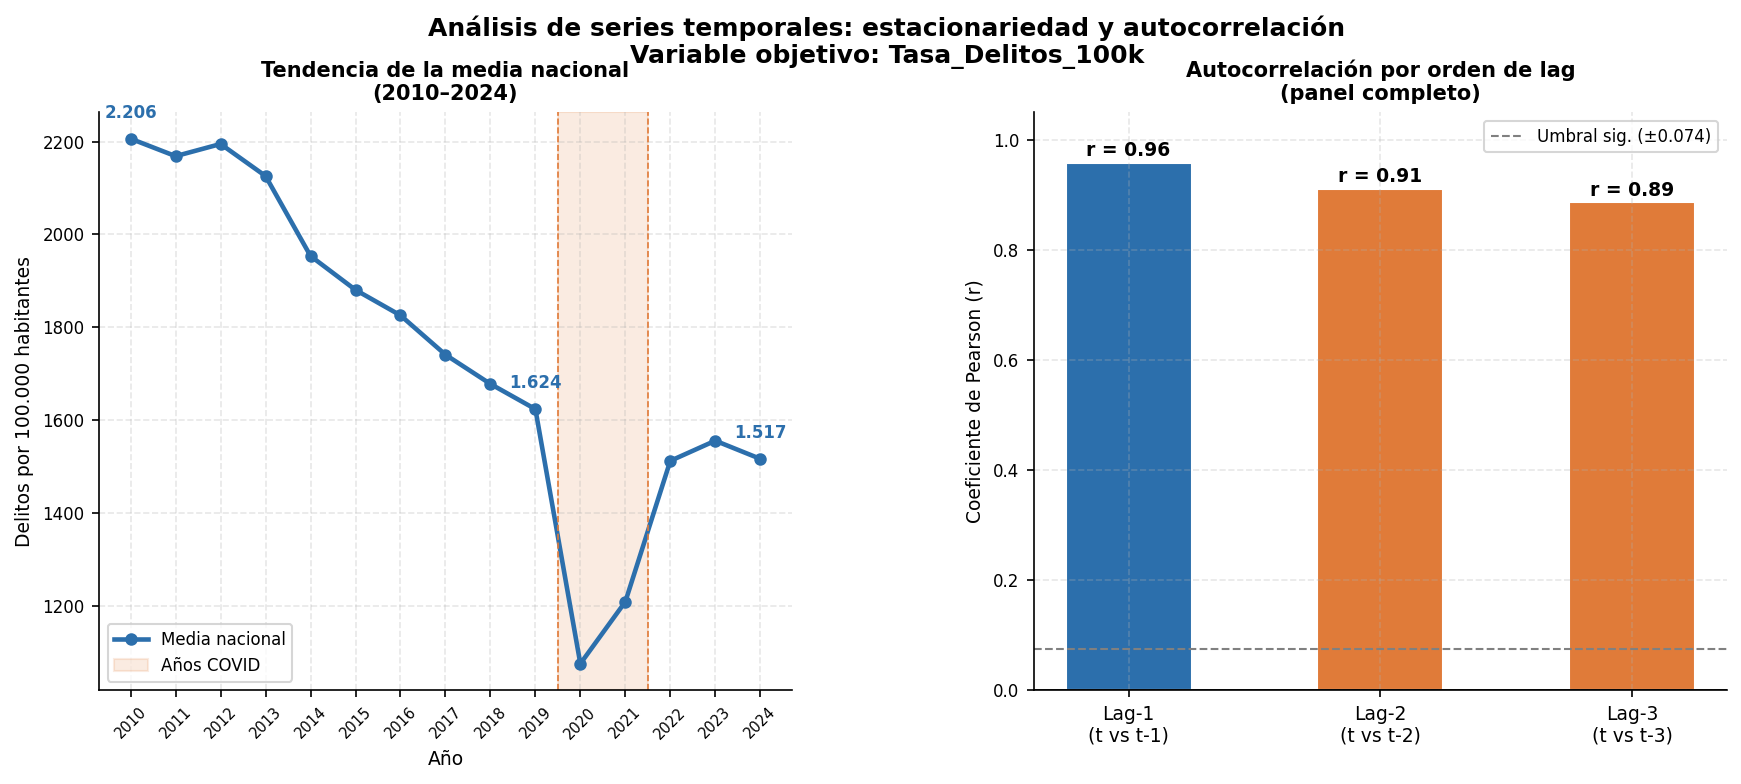

Figura guardada: ilustracion_series_temporales_acf.png


In [26]:
# ============================================================
# SECCIÓN 4.5.11 — Análisis de series temporales: estacionariedad y autocorrelación
# ============================================================


df = pd.read_csv('base_datos_maestra.csv', encoding='utf-8-sig')
df = df.sort_values(['Provincia', 'Año'])

# --- Calcular lags por provincia ---
df['lag1'] = df.groupby('Provincia')['Tasa_Delitos_100k'].shift(1)
df['lag2'] = df.groupby('Provincia')['Tasa_Delitos_100k'].shift(2)
df['lag3'] = df.groupby('Provincia')['Tasa_Delitos_100k'].shift(3)

r1 = df['Tasa_Delitos_100k'].corr(df['lag1'])
r2 = df['Tasa_Delitos_100k'].corr(df['lag2'])
r3 = df['Tasa_Delitos_100k'].corr(df['lag3'])

print(f"Autocorrelación lag-1: r = {r1:.4f}")
print(f"Autocorrelación lag-2: r = {r2:.4f}")
print(f"Autocorrelación lag-3: r = {r3:.4f}")

# --- Media nacional por año ---
media_anual = df.groupby('Año')['Tasa_Delitos_100k'].mean().reset_index()

# ---- FIGURA: 2 paneles ----------------------------------------
fig = plt.figure(figsize=(14, 5))
fig.suptitle(
    'Análisis de series temporales: estacionariedad y autocorrelación\n'
    'Variable objetivo: Tasa_Delitos_100k',
    fontsize=12, fontweight='bold', y=1.01
)
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

COLOR_LINE  = '#2C6FAC'
COLOR_COVID = '#E07B39'
COLOR_BAR   = '#2C6FAC'
COLOR_DECAY = '#E07B39'

# ── Panel 1: Tendencia temporal (media nacional) ───────────────
ax1 = fig.add_subplot(gs[0, 0])

ax1.plot(media_anual['Año'], media_anual['Tasa_Delitos_100k'],
         color=COLOR_LINE, linewidth=2.2, marker='o', markersize=5, label='Media nacional')

# Sombrear años COVID
ax1.axvspan(2019.5, 2021.5, color=COLOR_COVID, alpha=0.15, label='Años COVID')
ax1.axvline(2019.5, color=COLOR_COVID, linewidth=0.8, linestyle='--')
ax1.axvline(2021.5, color=COLOR_COVID, linewidth=0.8, linestyle='--')

# Anotar valores clave
for año, etiqueta in [(2010, '2.206'), (2019, '1.624'), (2024, '1.517')]:
    val = media_anual.loc[media_anual['Año'] == año, 'Tasa_Delitos_100k'].values[0]
    ax1.annotate(etiqueta,
                 xy=(año, val),
                 xytext=(0, 10), textcoords='offset points',
                 ha='center', fontsize=8, color=COLOR_LINE, fontweight='bold')

ax1.set_title('Tendencia de la media nacional\n(2010–2024)', fontsize=10, fontweight='bold')
ax1.set_xlabel('Año', fontsize=9)
ax1.set_ylabel('Delitos por 100.000 habitantes', fontsize=9)
ax1.set_xticks(media_anual['Año'])
ax1.set_xticklabels(media_anual['Año'], rotation=45, fontsize=7)
ax1.tick_params(axis='y', labelsize=8)
ax1.legend(fontsize=8)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── Panel 2: Barras de autocorrelación (lag 1, 2, 3) ──────────
ax2 = fig.add_subplot(gs[0, 1])

lags   = ['Lag-1\n(t vs t-1)', 'Lag-2\n(t vs t-2)', 'Lag-3\n(t vs t-3)']
valores = [r1, r2, r3]
colores = [COLOR_BAR, COLOR_DECAY, COLOR_DECAY]

bars = ax2.bar(lags, valores, color=colores, edgecolor='white', width=0.5)

# Línea de referencia en 0
ax2.axhline(0, color='black', linewidth=0.8)

# Umbral de significación aproximado (2/√N, N = nº pares válidos)
n_pares = df['lag1'].notna().sum()
umbral  = 2 / np.sqrt(n_pares)
ax2.axhline(umbral,  color='grey', linewidth=1, linestyle='--', label=f'Umbral sig. (±{umbral:.3f})')
ax2.axhline(-umbral, color='grey', linewidth=1, linestyle='--')

# Anotar valores en las barras
for bar, val in zip(bars, valores):
    ax2.text(bar.get_x() + bar.get_width()/2,
             val + 0.005,
             f'r = {val:.2f}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.set_title('Autocorrelación por orden de lag\n(panel completo)', fontsize=10, fontweight='bold')
ax2.set_ylabel('Coeficiente de Pearson (r)', fontsize=9)
ax2.set_ylim(0, 1.05)
ax2.tick_params(axis='x', labelsize=9)
ax2.tick_params(axis='y', labelsize=8)
ax2.legend(fontsize=8)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.savefig('ilustracion_series_temporales_acf.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: ilustracion_series_temporales_acf.png")